# Time evolution III — Krylov propagation and the integrator shoot-out

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 5 — Ground states and unitary dynamics*

## 1. Introduction and motivation

**Where we are.** We want $|\psi(t)\rangle=e^{-iHt}|\psi(0)\rangle$ for a chain of $N$ spins, with the state stored as a tensor of $2^N$ amplitudes and the Hamiltonian available only through
its action $|\phi\rangle\mapsto H|\phi\rangle$ ([Matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb)). So far we have met three ways to do it:

* **exact diagonalisation** ([textbook way](../ch02_spin_systems_textbook_way/04_time_evolution_the_textbook_way.ipynb)): perfect, but $\mathcal O(4^N)$ memory and $\mathcal O(8^N)$ time — dead at $N\approx14$;
* **TEBD / Trotter–Suzuki** ([previous-but-one notebook](12_tebd_trotter_suzuki.ipynb)): split $e^{-iH\,dt}$ into local gates; exactly unitary, error $\mathcal O(dt^p)$ with $p=1,2,4$;
* **Chebyshev expansion** ([previous notebook](13_chebyshev_propagation.ipynb)): a fixed, near-optimal polynomial in $H$ with Bessel-function coefficients; machine precision for $\approx a t$ applications of $H$
  ($a$ = half the spectral width), but it needs bounds on the spectrum.

**This notebook has two parts.**

*Part A — the Krylov (Lanczos) propagator.* Chebyshev uses the same polynomial for every initial state. The Krylov method asks a sharper question: *given this particular state $|\psi\rangle$ and a budget of $m$ applications of $H$, what is the best
approximation to $e^{-iHt}|\psi\rangle$ that can be built from the vectors $|\psi\rangle, H|\psi\rangle,\dots,H^{m-1}|\psi\rangle$?* The answer — project the Schrödinger equation onto the space spanned by these vectors and solve the tiny $m\times m$ problem exactly — is not literally the optimal
element of that space (§2.5 says in which sense it is nearly optimal, and measures how nearly). It needs no knowledge of the spectrum, conserves norm and energy exactly, and comes with a computable error bound that lets the algorithm choose its own time step. It was introduced for quantum dynamics by Park and Light (1986) and is the engine behind
general-purpose "matrix exponential times vector" software; it is also the standard time-evolution method of large-scale exact-diagonalisation studies of quantum chaos and many-body localisation.

*Part B — the shoot-out.* With four integrator families in hand, we do what a practitioner must do before a production run: **measure** accuracy versus cost — against a dense exact reference, with compilation time separated from run time,
as a function of the accuracy target and of the system size $N$ — and condense the outcome into a guidance table, *which integrator when*.

**Road map.** §2 the Krylov idea and its derivation; §3 a jit-compiled Lanczos with `lax.scan`, validated; §4 the Krylov step, convergence in $m$ and $dt$, comparison with Chebyshev; §5 the a-posteriori error bound and adaptive time stepping; §6 the exact dense reference and its cost;
§7 physics interlude — the Loschmidt echo as the integrator's hardest exam; §8 work–precision diagram of all integrators; §9 scaling with $N$ at fixed accuracy, memory and compile time; §10 guidance table; then summary, exercises, references.

### What you will learn

*Physics*

* the Loschmidt echo (return probability) after a quench, and why tiny overlaps demand accurate integrators;
* which conserved quantities an integrator respects *by construction* — and why those cannot then serve as accuracy checks.

*Numerical methods*

* Krylov subspaces, the Lanczos relation $HV_m=V_mT_m+\beta_m v_{m+1}e_m^{T}$, Galerkin projection of the Schrödinger equation;
* why the Krylov approximation is exact through order $t^{m-1}$ and converges super-exponentially once $m\gtrsim a\,t$;
* residual-based a-posteriori error bounds (via Duhamel's formula) and adaptive step-size control;
* cost models (time, memory) of exact, TEBD, Chebyshev and Krylov propagation and their measured crossovers.

*Implementation practice*

* a fixed-size, jit-able Lanczos iteration with `lax.scan` and full re-orthogonalisation (no Python-side convergence checks);
* `lax.while_loop` for adaptive stepping with a data-dependent number of steps;
* honest benchmarking: `block_until_ready`, compile time vs run time, best-of-$n$ timing, equal-accuracy comparisons, validated references for sizes where no exact answer exists.

### Prerequisites
[Hamiltonians and ground states](11_hamiltonians_and_ground_states.ipynb) (Lanczos iteration), [TEBD](12_tebd_trotter_suzuki.ipynb), [Chebyshev propagation](13_chebyshev_propagation.ipynb);
from Chapters 1 and 3: [JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) (`jit`, `scan`), [Matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## Engine recap

The folded cell holds the primitives used below: `apply_gate`, `heisenberg_terms`, `apply_hamiltonian`, `energy`, the dense validation tools `dense_hamiltonian` and `exact_evolve`, the TEBD gate builder `tebd_gates`,
`spectral_bounds` (for Chebyshev), and the engine's reference implementations `lanczos` and `krylov_evolve`, against which we check the jit-able versions developed in this notebook.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (copied from quantum_engine.py, the SmoQ.jax engine)
# Every function below is explained, with its mathematics and an independent check, in
# notebook 08b (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi

def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def spectral_bounds(terms, N, m=40, key=None):
    """Cheap estimate of (E_min, E_max) from a short Lanczos run -- needed to rescale H into [-1,1]
    for the Chebyshev expansion."""
    key = jax.random.PRNGKey(1) if key is None else key
    a, b, _ = lanczos(jax.jit(lambda p: apply_hamiltonian(terms, p)), haar_state(key, N), m)
    w = np.linalg.eigvalsh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
    return float(w[0]), float(w[-1])

def krylov_evolve(psi, terms, t, m=30):
    """exp(-iHt)|psi> in an m-dimensional Krylov space:
        |psi(t)> ~ ||psi|| * V exp(-i T t) e_1 ,      T = V^dag H V  (tridiagonal, from Lanczos).
    Exact for polynomials of degree < m in H; accurate as long as  |t| * (spectral width)  <~  m.
    For long times: chain several short Krylov steps."""
    nrm = jnp.linalg.norm(psi)
    a, b, V = lanczos(jax.jit(lambda p: apply_hamiltonian(terms, p)), psi, m)
    w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
    c = S_ @ (np.exp(-1j * t * w) * S_[0, :])
    return nrm * jnp.tensordot(jnp.asarray(c, dtype=CDTYPE), V, axes=1)

def exact_evolve(psi, terms, t):
    """Dense reference for small N: full diagonalisation H = V w V^dag, |psi(t)> = V e^{-i w t} V^dag |psi>.
    O(8^N) time, O(4^N) memory -- the wall that matrix-free methods avoid; used only to validate them."""
    N = psi.ndim
    w, v = jnp.linalg.eigh(dense_hamiltonian(terms, N))
    return ((v * jnp.exp(-1j * t * w)) @ (v.conj().T @ psi.reshape(-1))).reshape((2,) * N)


## 2. The Krylov idea

### 2.1 Everything we can compute lives in a Krylov space

With $m-1$ applications of $H$ to a normalised start vector $|v_1\rangle=|\psi\rangle/\|\psi\|$ we can reach exactly the vectors of the **Krylov subspace**

$$ \mathcal K_m(H,\psi)=\mathrm{span}\big\{|\psi\rangle,\;H|\psi\rangle,\;H^2|\psi\rangle,\;\dots,\;H^{m-1}|\psi\rangle\big\}=\big\{p(H)|\psi\rangle:\ \deg p\le m-1\big\}. $$

Truncated Taylor series, Chebyshev sums — every polynomial method picks *some* element of this space. The Krylov method lets the Schrödinger equation itself choose the element.

### 2.2 An orthonormal basis: Lanczos in one paragraph

The raw vectors $H^k|\psi\rangle$ are a terrible basis (they all turn towards the eigenvector with the largest $|E|$ and become numerically parallel). The **Lanczos iteration**, derived in
[Hamiltonians and ground states](11_hamiltonians_and_ground_states.ipynb), orthonormalises them on the fly. For Hermitian $H$ each new vector needs to be orthogonalised only against the previous two:

$$ \beta_j|v_{j+1}\rangle = H|v_j\rangle-\alpha_j|v_j\rangle-\beta_{j-1}|v_{j-1}\rangle,\qquad \alpha_j=\langle v_j|H|v_j\rangle,\qquad \beta_j=\big\|\,H v_j-\alpha_jv_j-\beta_{j-1}v_{j-1}\big\| . $$

Collect the vectors as the columns of the $2^N\times m$ matrix $V_m=[v_1,\dots,v_m]$. The recurrence, written for all $j=1..m$ at once, is the **Lanczos relation**

$$ \boxed{\,H\,V_m = V_m\,T_m+\beta_m\,|v_{m+1}\rangle\, e_m^{T}\,},\qquad
   T_m=V_m^\dagger HV_m=\begin{pmatrix}\alpha_1&\beta_1\\ \beta_1&\alpha_2&\beta_2\\ &\beta_2&\ddots&\ddots\\ &&\ddots&\alpha_{m-1}&\beta_{m-1}\\&&&\beta_{m-1}&\alpha_m\end{pmatrix}, \qquad (1)$$

with $e_m=(0,\dots,0,1)^T$. In words: inside the Krylov space $H$ acts as the small real symmetric tridiagonal matrix $T_m$; the *only* way $H$ leads out of the space is from the last vector $v_m$ into the next one $v_{m+1}$, with amplitude $\beta_m$.

### 2.3 Projecting the Schrödinger equation

Make the *ansatz* that the state stays in the Krylov space, $|\psi_m(t)\rangle=V_m\,c(t)$ with $c(t)\in\mathbb C^m$, and demand that the Schrödinger equation holds *within* that space (a **Galerkin condition**: the residual must be
orthogonal to all basis vectors): $V_m^\dagger\big(i\partial_t-H\big)V_mc=0$. With $V_m^\dagger V_m=1$ and $V_m^\dagger HV_m=T_m$:

$$ i\,\dot c=T_m\,c,\quad c(0)=\|\psi\|\,e_1\qquad\Longrightarrow\qquad \boxed{\,|\psi_m(t)\rangle=\|\psi\|\;V_m\;e^{-iT_mt}\,e_1\,} \qquad (2)$$

The $2^N$-dimensional exponential has been replaced by an $m\times m$ one ($m\sim10$–$50$), which we compute *exactly* by diagonalising $T_m=S\,\mathrm{diag}(\theta)\,S^{T}$:
$e^{-iT_mt}e_1=S\,\big(e^{-i\theta t}\odot S^{T}e_1\big)$.

### 2.4 Three exact properties

**(a) Exact through order $t^{m-1}$.** Claim: $H^jv_1=V_mT_m^je_1$ for $j=0,1,\dots,m-1$. Proof by induction: true for $j=0$; if true for $j$, then using (1)
$H^{j+1}v_1=HV_mT_m^je_1=V_mT_m^{j+1}e_1+\beta_mv_{m+1}\,\big(e_m^TT_m^je_1\big)$. Since $T_m$ is tridiagonal, $T_m^j$ has non-zero entries only within $j$ places from the diagonal, so its $(m,1)$ entry vanishes for $j<m-1$. $\blacksquare$
Hence (2) reproduces the Taylor series of $e^{-iHt}|\psi\rangle$ up to and including the term $t^{m-1}$, and the error of one step is $\mathcal O(t^m)$: **a Krylov step of dimension $m$ is an integrator of order $m-1$.** Unlike a Taylor polynomial it does not suffer from
cancellation (we never sum large terms; $e^{-iT_mt}$ is an exactly unitary small matrix) and — as we will measure — it converges for *large* steps too, once $m$ exceeds roughly $a\,t$, just like Chebyshev.
The first term the identity misses is the one with $j=m$, where the defect is exactly $\beta_m\,\beta_1\cdots\beta_{m-1}=\beta_1\cdots\beta_m$ (Exercise 1).

**(b) Norm is conserved exactly**, for any $m$ and $t$: $\|\psi_m(t)\|=\|c(t)\|=\|\psi\|$, because $V_m$ has orthonormal columns and $e^{-iT_mt}$ is unitary.
In floating point the statement is worth exactly as much as the orthonormality of $V_m$. The implementation of §3 re-orthogonalises fully and keeps $\max|V_m^\dagger V_m-1|\sim10^{-15}$ (measured below), so the norm is conserved to rounding.
A plain three-term recurrence loses orthogonality as soon as a Ritz pair converges ([Hamiltonians and ground states](11_hamiltonians_and_ground_states.ipynb)) and loses this guarantee with it: at $N=10$, $m=80$, $dt=8$ the norm then drifts by $5\times10^{-5}$ while the re-orthogonalised version stays at $2\times10^{-16}$ (Exercise 3).

**(c) Energy is conserved exactly:** $\langle\psi_m(t)|H|\psi_m(t)\rangle=c^\dagger V_m^\dagger HV_mc=c^\dagger T_mc$, which is constant under $i\dot c=T_mc$.

> **Common pitfall.** Properties (b) and (c) hold *even when the approximation is completely wrong* (too small $m$, too large $t$). For the Krylov method, norm and energy conservation are therefore **useless as accuracy diagnostics** — the opposite of the Chebyshev
> method, where a drifting norm was the first alarm signal. We need a different error indicator; §5 derives one.

### 2.5 The sense in which this is the best approximation

The Galerkin state (2) is *not* the best element of $\mathcal K_m$. The best element is the orthogonal projection $V_mV_m^\dagger e^{-iHt}|\psi\rangle$ of the exact state onto the subspace, and forming it requires the answer we are trying to compute. What can be proved is that (2) is never much worse.
Let $p$ be *any* polynomial of degree $\le m-1$ and write $f(E)=e^{-iEt}$. By property (a), $p(H)|\psi\rangle=\|\psi\|\,V_m\,p(T_m)e_1$, so the two polynomial pieces cancel in

$$ \big\|\psi_m(t)-\psi(t)\big\|=\Big\|\,\|\psi\|V_m\big[f(T_m)-p(T_m)\big]e_1-\big[f(H)-p(H)\big]|\psi\rangle\Big\|\le\|\psi\|\Big(\max_{\theta\in\sigma(T_m)}\big|f(\theta)-p(\theta)\big|+\max_{E\in\sigma(H)}\big|f(E)-p(E)\big|\Big), $$

using $\|V_m\|=1$ and, for each Hermitian matrix, that the norm of a function of it is the largest value of that function on its spectrum. The eigenvalues of $T_m=V_m^\dagger HV_m$ are Rayleigh quotients of $H$ and therefore lie in $[E_{\min},E_{\max}]$: both maxima are bounded by the maximum over the *same* interval. Minimising over $p$,

$$ \boxed{\;\big\|\psi_m(t)-\psi(t)\big\|\;\le\;2\,\|\psi\|\!\!\min_{\deg p\le m-1}\ \max_{E_{\min}\le E\le E_{\max}}\big|e^{-iEt}-p(E)\big|\;} \qquad (2a) $$

The Krylov approximation is thus within a factor $2$ of the *best possible* polynomial of degree $m-1$ — it is **quasi-optimal**. (The inequality one line above (2a) is Lemma 4.1 of Saad (1992); we have only specialised it to Hermitian $H$.) Three consequences, all of them practical.

**Only the spectral width matters, not $\|H\|$.** Replacing $H$ by $H+c\,\mathbb 1$ leaves every $v_j$ and every $\beta_j$ unchanged and shifts every $\alpha_j$ by $c$, so $T_m\to T_m+c\,\mathbb 1$ and $|\psi_m\rangle\to e^{-ict}|\psi_m\rangle$: the approximation error is untouched. The right-hand side of (2a) is shift invariant for the same reason.
The scale that controls everything is therefore the **spectral half-width** $a=(E_{\max}-E_{\min})/2$, and not $\|H\|$, which can be made arbitrarily large by adding a constant to $H$ without changing the physics or the difficulty of the problem.

**The Chebyshev estimate of the previous notebook carries over unchanged.** Take for $p$ the Chebyshev expansion of $e^{-iEt}$ truncated after degree $m-1$. Its error is at most the sum of the omitted coefficients, $\sum_{k\ge m}2|J_k(a\,t)|\le4\big(e\,a\,t/2m\big)^{m}$ for $m\ge a\,t$ ([Chebyshev propagation](13_chebyshev_propagation.ipynb), Stirling form of the Bessel bound), so (2a) gives

$$ \big\|\psi_m(t)-\psi(t)\big\|\;\le\;8\,\|\psi\|\left(\frac{e\,a\,t}{2m}\right)^{m},\qquad m\ge a\,t . \qquad (2b) $$

The right-hand side starts to fall once $m>e\,a\,t/2\approx1.36\,a\,t$ and then drops by a further factor $e\,a\,t/2m$ with every extra Lanczos vector — super-exponential convergence, with the same threshold $m\sim a\,t$ as Chebyshev.
The sharp version of the same statement is Theorem 4 of Hochbruck and Lubich (1997): for a skew-Hermitian generator $-iH$ whose spectrum fills an interval of length $4\rho=E_{\max}-E_{\min}$ (so that $\rho=a/2$),

$$ \big\|\psi_m(t)-\psi(t)\big\|\;\le\;12\,\|\psi\|\;e^{-(\rho t)^2/m}\left(\frac{e\,\rho\,t}{m}\right)^{m}=12\,\|\psi\|\;e^{-(a t)^2/4m}\left(\frac{e\,a\,t}{2m}\right)^{m},\qquad m\ge2\rho t=a\,t . \qquad (2b') $$

The geometric factor is the same as in (2b); the Gaussian in front makes the decay set in faster. The same paper states the negative half of the result: for a skew-Hermitian generator with eigenvalues spread over the whole interval, *no* super-linear decay can be proved below $m\approx\rho t$. The threshold in (2b) is not an artefact of our elementary derivation.

**The practical rule.** Choose $m$ and $dt$ together so that $m$ exceeds $a\,dt$ by a safety margin. Over the whole range measured in §4.2 ($a\,dt=1.7$ to $35$) ten digits of accuracy require

$$ m\;\gtrsim\;a\,dt+15 . \qquad (2c) $$

Read backwards: with a memory budget of $m$ vectors the longest useful step is $dt\approx(m-15)/a$; steps longer than that spend applications of $H$ on an approximation that has not converged. The adaptive algorithm of §5.2 enforces the same discipline automatically, from the error bound rather than from a rule of thumb.

## 3. A jit-compiled Lanczos iteration

### 3.1 Design decisions

The engine's `lanczos` (see the recap) is a Python loop that stops early when $\beta_j$ becomes tiny — this requires pulling a number from the device to Python at every iteration (`float(b)`), so it cannot be compiled as a whole. For time evolution the Lanczos
iteration sits *inside* the time loop and is executed thousands of times, so we want a version that compiles into a single XLA program:

* **fixed number of iterations $m$** $\Rightarrow$ `lax.scan` over $j=0,\dots,m-1$ (see [JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb));
* the basis is a **pre-allocated array** `V` of shape $(m,2^N)$, filled row by row with the functional update `V.at[j+1].set(v)` (JAX arrays are immutable; under `jit` XLA performs the update in place);
* **full re-orthogonalisation** in matrix form. In exact arithmetic the three-term recurrence suffices; in floating point orthogonality is gradually lost ([Hamiltonians and ground states](11_hamiltonians_and_ground_states.ipynb)).
  We therefore subtract from $w=Hv_j$ its projection onto *all* rows stored so far, $w\leftarrow w-V^{T}(V^{*}w)$ — two matrix–vector products. Rows not yet filled are zero and contribute nothing, so no masking is needed.
  This also removes the $\alpha_jv_j$ and $\beta_{j-1}v_{j-1}$ terms automatically. We do it twice ("twice is enough", a classical result for Gram–Schmidt re-orthogonalisation; Golub and Van Loan);
* **no early exit**: if $\beta_j\approx0$ (the Krylov space is *invariant* — the state lives in fewer than $m$ eigenvectors, and the projection is already exact) we must not divide by it. `jnp.where` replaces the next vector by zero; all later $\alpha,\beta$ are then zero, $T_m$ becomes block-diagonal and the result (2) is unaffected.

**From formula to code.** With `V` of shape `(m, dim)` holding the basis vectors as *rows*: `V.conj() @ w` is the vector of overlaps $\langle v_i|w\rangle$, shape `(m,)`; `V.T @ overlaps` is $\sum_i\langle v_i|w\rangle\,v_i$, shape `(dim,)`.
The state tensor of shape $(2,)^N$ is flattened for these products and reshaped only to apply $H$.

In [3]:
# ==============================================================================
# PARAMETERS of the model used in the whole notebook: XXZ chain in a transverse field (non-integrable)
#     H = sum_j (Jxx X_j X_j+1 + Jyy Y_j Y_j+1 + Jzz Z_j Z_j+1) + hx sum_j X_j      (Pauli convention, open chain)
# ==============================================================================
JXX, JYY, JZZ, HX = 1.0, 1.0, 0.5, 1.0


def model_terms(N):
    """The Hamiltonian as a list of local terms [(qubits, matrix), ...]."""
    return heisenberg_terms(N, Jxx=JXX, Jyy=JYY, Jzz=JZZ, hx=HX)


def make_matvec(terms):
    """Return the function |phi> -> H|phi>  (matrix-free: one einsum per local term)."""
    return lambda phi: apply_hamiltonian(terms, phi)


# ==============================================================================
# STEP 1: Lanczos iteration as a lax.scan  (fixed m, full re-orthogonalisation, jit-able)
# ==============================================================================
def lanczos_basis(matvec, psi, m):
    """m steps of Lanczos started from psi/||psi||.   Returns (alphas[m], betas[m], V[m, 2^N]).

    MATH            beta_j v_{j+1} = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>
                    =>  H V_m = V_m T_m + beta_m v_{m+1} e_m^T,     T_m = tridiag(beta, alpha, beta)          [Eq. (1)]
                    `betas[j]` is the norm of the (j+1)-th residual; the LAST one, betas[m-1] = beta_m, does not enter T_m
                    but measures the leakage out of the Krylov space (needed for the error bound of section 5).
    IMPLEMENTATION  V is pre-allocated (rows = basis vectors, unused rows are zero).  Re-orthogonalisation against ALL
                    stored vectors, twice:  w <- w - V^T (V^* w).   Breakdown (beta ~ 0) is handled with jnp.where.
    COST            m applications of H  +  O(m^2 2^N) for the re-orthogonalisation;   memory  m + 2 state vectors.
    JAX             m is static (array shapes depend on it); psi is traced -> usable inside jit / scan / while_loop.
    """
    shape, dim = psi.shape, psi.size
    v0 = (psi / jnp.linalg.norm(psi)).reshape(-1)
    V0 = jnp.zeros((m, dim), dtype=psi.dtype).at[0].set(v0)

    def body(carry, j):
        V, v = carry
        w = matvec(v.reshape(shape)).reshape(-1)                 # H v_j
        alpha = jnp.real(jnp.vdot(v, w))                         # <v_j|H|v_j>
        w = w - V.T @ (V.conj() @ w)                             # remove the components along all stored v_i ...
        w = w - V.T @ (V.conj() @ w)                             # ... twice (cures rounding errors of the first pass)
        beta = jnp.linalg.norm(w)
        ok = beta > 1e3 * jnp.finfo(RDTYPE).eps                  # invariant subspace reached?  then stop adding vectors
        v_next = jnp.where(ok, w / jnp.where(ok, beta, 1.0), 0.0)
        V = V.at[j + 1].set(v_next, mode="drop")                 # row m does not exist: that update is dropped
        return (V, v_next), (alpha, jnp.where(ok, beta, 0.0))

    (V, _), (alphas, betas) = lax.scan(body, (V0, v0), jnp.arange(m))
    return alphas, betas, V


def tridiagonal(alphas, betas):
    """T_m = tridiag(betas[:-1], alphas, betas[:-1])   (m x m, real symmetric)."""
    return jnp.diag(alphas) + jnp.diag(betas[:-1], 1) + jnp.diag(betas[:-1], -1)


# ------------------------------------------------------------------------------
# CHECKPOINT (N = 10, dense reference): orthonormality, T = V^+ H V, the Lanczos relation, agreement with the engine
# ------------------------------------------------------------------------------
N_val = 10
terms_val = model_terms(N_val)
matvec_val = make_matvec(terms_val)
psi0_val = zero_state(N_val)                                     # |00...0>: all spins up along z
H_dense = dense_hamiltonian(terms_val, N_val)                    # validation only (1024 x 1024)

m_chk = 40
alphas, betas, V = jax.jit(lanczos_basis, static_argnums=(0, 2))(matvec_val, psi0_val, m_chk)
T_m = tridiagonal(alphas, betas)
err_orth = float(jnp.max(jnp.abs(V.conj() @ V.T - jnp.eye(m_chk))))
err_proj = float(jnp.max(jnp.abs(V.conj() @ H_dense @ V.T - T_m)))
# Lanczos relation (1), row convention:  H V^T = V^T T + beta_m v_{m+1} e_m^T   =>  the residual has ONLY a last column, of norm beta_m
R = H_dense @ V.T - V.T @ T_m.astype(CDTYPE)
err_rel = float(jnp.max(jnp.abs(R[:, :-1])))
a_eng, b_eng, _ = lanczos(jax.jit(matvec_val), psi0_val, m=m_chk)
print(f"orthonormality   max|V^+ V - 1|                 = {err_orth:.1e}")
print(f"projection       max|V^+ H V - T_m|             = {err_proj:.1e}")
print(f"Lanczos relation max|(H V - V T)[:, :m-1]|      = {err_rel:.1e}")
print(f"last column      ||(H V - V T)[:, m-1]|| = {float(jnp.linalg.norm(R[:, -1])):.6f}   vs  beta_m = {float(betas[-1]):.6f}")
print(f"engine lanczos   max|alpha - alpha_engine| = {np.max(np.abs(np.asarray(alphas) - a_eng)):.1e},  "
      f"max|beta - beta_engine| = {np.max(np.abs(np.asarray(betas[:-1]) - b_eng)):.1e}")
assert max(err_orth, err_proj, err_rel) < 100 * TOL
assert abs(float(jnp.linalg.norm(R[:, -1])) - float(betas[-1])) < 100 * TOL

orthonormality   max|V^+ V - 1|                 = 4.4e-16
projection       max|V^+ H V - T_m|             = 5.3e-15
Lanczos relation max|(H V - V T)[:, :m-1]|      = 1.0e-15


last column      ||(H V - V T)[:, m-1]|| = 6.315188   vs  beta_m = 6.315188
engine lanczos   max|alpha - alpha_engine| = 4.8e-14,  max|beta - beta_engine| = 2.5e-14


**Interpretation.** The basis is orthonormal to $\sim10^{-15}$, the projected Hamiltonian *is* the tridiagonal matrix, and the residual $HV_m-V_mT_m$ vanishes in all columns but the last, whose norm equals $\beta_m$ — Eq. (1), verified entry by entry.
The coefficients agree with the engine's Python-loop Lanczos to rounding accuracy.

> **JAX practice.** `jax.jit(f, static_argnums=(0, 2))` declares the arguments `matvec` (a Python function) and `m` (which fixes array shapes) as *static*: they are baked into the compiled program, and a new value triggers a new compilation.
> Everything else (`psi`) is traced.

> **Numerical practice.** Full re-orthogonalisation costs $\mathcal O(m\,2^N)$ per iteration, comparable to one application of $H$ (which is $\sim 4\cdot2N\cdot2^N$ multiplications here) when $m\sim30$. For short Krylov spaces this is a fair price for robustness. The memory, $m$ vectors, is the real limitation of the method.

## 4. The Krylov step: implementation, validation, convergence

### 4.1 From formula to code

Eq. (2) in four lines: build $(\alpha,\beta,V)$; diagonalise $T_m=S\,\mathrm{diag}(\theta)S^T$ with `jnp.linalg.eigh` (an $m\times m$ problem — negligible cost); form the coefficient vector $c=S\,(e^{-i\theta\,dt}\odot S_{0,:})$, where `S[0, :]` $=S^Te_1$ is the first *row* of $S$;
return $\|\psi\|\sum_jc_jv_j$ = `c @ V`. Everything is traced, so `dt` can be changed without recompiling.

In [4]:
# ==============================================================================
# STEP 2: one Krylov step   |psi> -> exp(-i H dt)|psi>
# ==============================================================================
def krylov_coefficients(alphas, betas, dt):
    """c(dt) = exp(-i T_m dt) e_1   via the eigendecomposition of the small tridiagonal matrix T_m = S diag(theta) S^T."""
    theta, S = jnp.linalg.eigh(tridiagonal(alphas, betas))
    return S.astype(CDTYPE) @ (jnp.exp(-1j * dt * theta) * S[0, :])


def krylov_step(matvec, psi, dt, m):
    """exp(-i H dt)|psi>  approximated in the m-dimensional Krylov space:   ||psi|| V_m exp(-i T_m dt) e_1      [Eq. (2)]

    PROPERTIES  exact through order dt^(m-1); norm and energy conserved exactly; accurate when m >~ (spectral half-width)*dt.
    COST        m applications of H + O(m^2 2^N) re-orthogonalisation + O(m^3) small eigenproblem;  memory m+2 vectors.
    JAX         `matvec` and `m` static, (psi, dt) traced.
    """
    alphas, betas, V = lanczos_basis(matvec, psi, m)
    c = krylov_coefficients(alphas, betas, dt)
    return jnp.linalg.norm(psi) * (c @ V).reshape(psi.shape)


krylov_step_jit = jax.jit(krylov_step, static_argnums=(0, 3))

# ------------------------------------------------------------------------------
# CHECKPOINT: against the dense exact propagator and against the engine's krylov_evolve   (N = 10, dt = 0.5, m = 30)
# ------------------------------------------------------------------------------
E_d, V_d = jnp.linalg.eigh(H_dense)                              # dense eigen-decomposition: validation only


def exact_state(psi0, t):
    """Dense reference  V exp(-i E t) V^+ |psi0>  (re-uses the single diagonalisation above)."""
    return (V_d @ (jnp.exp(-1j * E_d * t) * (V_d.conj().T @ psi0.reshape(-1)))).reshape(psi0.shape)


dt_chk, m_chk = 0.5, 30
psi_k = krylov_step_jit(matvec_val, psi0_val, dt_chk, m_chk)
err_exact = float(jnp.linalg.norm(psi_k - exact_state(psi0_val, dt_chk)))
err_engine = float(jnp.linalg.norm(psi_k - krylov_evolve(psi0_val, terms_val, dt_chk, m=m_chk)))
err_engine_exact = float(jnp.linalg.norm(exact_state(psi0_val, dt_chk) - exact_evolve(psi0_val, terms_val, dt_chk)))
print(f"|| krylov_step - exact ||          = {err_exact:.2e}")
print(f"|| krylov_step - engine krylov ||  = {err_engine:.2e}")
print(f"|| our dense reference - engine exact_evolve || = {err_engine_exact:.2e}")
assert max(err_exact, err_engine, err_engine_exact) < 100 * TOL

|| krylov_step - exact ||          = 2.73e-15
|| krylov_step - engine krylov ||  = 3.42e-15
|| our dense reference - engine exact_evolve || = 1.82e-16


**Interpretation.** Thirty applications of $H$ give $e^{-0.5\,iH}|\psi\rangle$ to machine precision, in agreement with the engine's (non-jitted) `krylov_evolve` and with the dense propagator.

### 4.2 Convergence in the subspace dimension $m$ — and a comparison with Chebyshev

We now measure the error of a single step as a function of $m$ for several step lengths, and for three different initial states: the product state $|0\dots0\rangle$, a Haar-random state (spread over the *whole* spectrum) and a local excitation of the ground state, $X_{N/2}|E_0\rangle$
(concentrated at the *bottom* of the spectrum; this is the kind of state that appears in the calculation of dynamical structure factors). For reference we overlay the error of the Chebyshev expansion of **equal cost**: $m$ applications of $H$ build the Chebyshev polynomial up to degree $m$,
whose leading omitted term is $2|J_{m+1}(a\,dt)|$ ([Chebyshev propagation](13_chebyshev_propagation.ipynb)). The spectral half-width $a$ that Chebyshev needs is taken from the dense spectrum here; Krylov needs no such input.
The cell also prints, for one step length, how far the Galerkin state (2) is from the *best* element of the same Krylov space — the numerical counterpart of §2.5.

**A trick that saves almost all the work: Krylov spaces are nested.** The first $m$ Lanczos vectors do not depend on how many more we compute afterwards. So a single run with $m_{\max}=64$ contains *every* smaller Krylov approximation: $V_m$ = the first $m$ rows of `V`, $T_m$ = the leading
$m\times m$ block of $T_{64}$. And since $V_m,T_m$ do not depend on $dt$ either, each initial state needs exactly one Lanczos run for the whole figure; everything else is small-matrix algebra, done here in NumPy.

> **JAX practice.** The three Lanczos runs differ only in the initial state, which is exactly what `jax.vmap` is for: `jax.vmap(lanczos_basis, in_axes=(None, 0, None))` maps over the batch axis of `psi` and leaves `matvec` and `m` alone, so one compiled program produces all three bases,
> with the matrix–vector products of the different states batched into single XLA calls. The same wrapper serves disorder realisations, quench parameters or a set of trial states without a Python loop.

$|0\dots0\rangle$       : <H> =    4.500,  energy spread = 3.162     (spectrum: [-15.18, 19.33], a = 17.25)
Haar random             : <H> =   -0.244,  energy spread = 5.329     (spectrum: [-15.18, 19.33], a = 17.25)
$X_{N/2}|E_0\rangle$    : <H> =  -11.700,  energy spread = 2.201     (spectrum: [-15.18, 19.33], a = 17.25)

quasi-optimality at dt = 1 (the best element of K_m is the orthogonal projection V_m V_m^+ |psi_exact>):


   m = 10:  Galerkin error 6.649e-01   best element of K_m 5.319e-01   ratio 1.25


   m = 20:  Galerkin error 1.235e-03   best element of K_m 1.163e-03   ratio 1.06


   m = 30:  Galerkin error 3.902e-09   best element of K_m 3.809e-09   ratio 1.02


   m = 40:  Galerkin error 4.328e-15   best element of K_m 3.099e-15   ratio 1.40


dt = 0.1 (a dt =   1.7):  error < 1e-10 needs  m = 11 applications of H (Krylov)   vs   K = 12 (Chebyshev)   ->  Krylov saves  8.3 %


dt = 0.5 (a dt =   8.6):  error < 1e-10 needs  m = 23 applications of H (Krylov)   vs   K = 25 (Chebyshev)   ->  Krylov saves  8.0 %


dt = 1.0 (a dt =  17.3):  error < 1e-10 needs  m = 33 applications of H (Krylov)   vs   K = 38 (Chebyshev)   ->  Krylov saves 13.2 %


dt = 2.0 (a dt =  34.5):  error < 1e-10 needs  m = 50 applications of H (Krylov)   vs   K = 60 (Chebyshev)   ->  Krylov saves 16.7 %


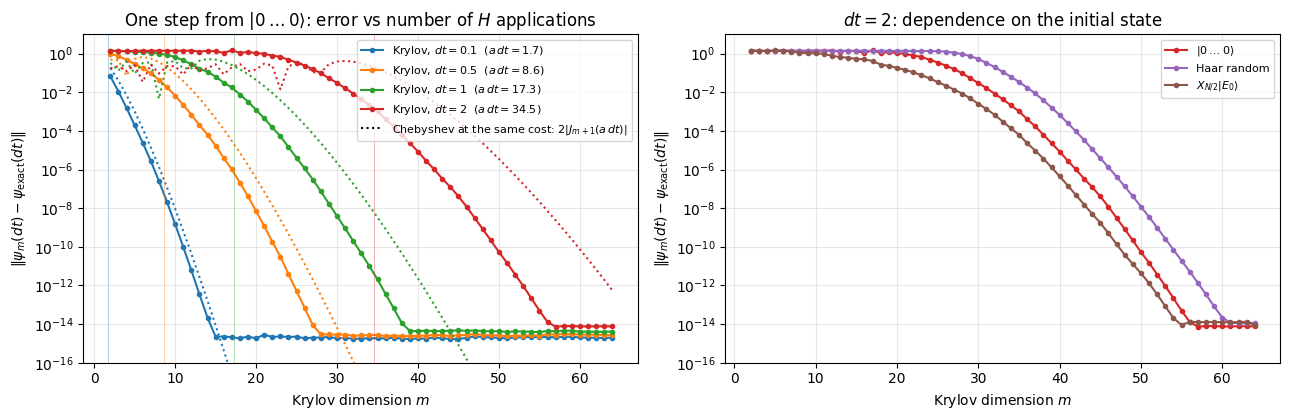

In [5]:
# ==============================================================================
# EXPERIMENT: single-step error versus Krylov dimension m  (N = 10), compared with Chebyshev at equal number of H applications
# ==============================================================================
from scipy.special import jv            # Bessel functions J_k(z): coefficients of the Chebyshev expansion (previous notebook)

M_MAX = 64


def krylov_state_nested(basis, m, dt):
    """Krylov approximation of dimension m <= M_MAX from a LONGER Lanczos run (nestedness): uses alphas[:m], betas[:m-1], V[:m]."""
    alphas, betas, V = basis
    theta, S = np.linalg.eigh(np.diag(alphas[:m]) + np.diag(betas[:m - 1], 1) + np.diag(betas[:m - 1], -1))
    c = S @ (np.exp(-1j * dt * theta) * S[0, :])
    return (jnp.asarray(c, dtype=CDTYPE) @ V[:m]).reshape((2,) * N_val)


a_true = float(E_d[-1] - E_d[0]) / 2                                     # spectral half-width (dense: validation only)
ground = V_d[:, 0].reshape((2,) * N_val)
psi_local = apply_gate(ground, X, [N_val // 2])                          # local spin flip on top of the ground state
states = {r"$|0\dots0\rangle$": psi0_val,
          "Haar random": haar_state(jax.random.PRNGKey(7), N_val),
          r"$X_{N/2}|E_0\rangle$": psi_local / jnp.linalg.norm(psi_local)}

# one compiled program, all three initial states at once: vmap maps over the batch axis of `psi` only
lanczos_batched = jax.jit(jax.vmap(lanczos_basis, in_axes=(None, 0, None)), static_argnums=(0, 2))
al_b, be_b, V_b = lanczos_batched(matvec_val, jnp.stack(list(states.values())), M_MAX)
bases = {name: (np.asarray(al_b[i]), np.asarray(be_b[i]), V_b[i]) for i, name in enumerate(states)}

for name, st in states.items():
    H_st = matvec_val(st)
    E_mean = float(jnp.real(jnp.vdot(st, H_st)))
    E_std = float(jnp.sqrt(jnp.real(jnp.vdot(H_st, H_st)) - E_mean ** 2))
    print(f"{name:24s}: <H> = {E_mean:8.3f},  energy spread = {E_std:.3f}     (spectrum: [{float(E_d[0]):.2f}, {float(E_d[-1]):.2f}], a = {a_true:.2f})")

# --- how far is the Galerkin state (2) from the BEST element of the same Krylov space?   [quasi-optimality, Eq. (2a)]
name0 = r"$|0\dots0\rangle$"
exact_flat = exact_state(psi0_val, 1.0).reshape(-1)
print("\nquasi-optimality at dt = 1 (the best element of K_m is the orthogonal projection V_m V_m^+ |psi_exact>):")
for m in (10, 20, 30, 40):
    V_m = bases[name0][2][:m]
    err_best = float(jnp.linalg.norm(exact_flat - V_m.T @ (V_m.conj() @ exact_flat)))
    err_gal = float(jnp.linalg.norm(krylov_state_nested(bases[name0], m, 1.0).reshape(-1) - exact_flat))
    print(f"   m = {m:2d}:  Galerkin error {err_gal:.3e}   best element of K_m {err_best:.3e}   ratio {err_gal / err_best:.2f}")

m_list = np.arange(2, M_MAX + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
# --- left: |0...0>, several dt, Krylov (solid) vs the Chebyshev expansion of EQUAL COST (dotted)
for col, dt in zip(("C0", "C1", "C2", "C3"), (0.1, 0.5, 1.0, 2.0)):
    exact_dt = exact_state(psi0_val, dt)
    errs = np.array([float(jnp.linalg.norm(krylov_state_nested(bases[name0], m, dt) - exact_dt)) for m in m_list])
    axes[0].semilogy(m_list, errs, "o-", ms=3, color=col, label=f"Krylov, $dt={dt:g}$  ($a\\,dt={a_true * dt:.1f}$)")
    # m applications of H build the Chebyshev polynomial up to degree m; the leading omitted term is then 2|J_{m+1}|
    axes[0].semilogy(m_list, 2 * np.abs(jv(m_list + 1, a_true * dt)) + 1e-300, ":", color=col)
    axes[0].axvline(a_true * dt, color=col, lw=0.5, alpha=0.5)
    m_ok = int(m_list[np.argmax(errs < 1e-10)])
    ks = np.arange(1, 200)
    K_ok = int(ks[np.argmax((2 * np.abs(jv(ks, a_true * dt)) < 1e-10) & (ks > a_true * dt))]) - 1     # degree kept = cost
    print(f"dt = {dt:3.1f} (a dt = {a_true * dt:5.1f}):  error < 1e-10 needs  m = {m_ok:2d} applications of H (Krylov)"
          f"   vs   K = {K_ok:2d} (Chebyshev)   ->  Krylov saves {100 * (1 - m_ok / K_ok):4.1f} %")
axes[0].plot([], [], "k:", label="Chebyshev at the same cost: $2|J_{m+1}(a\\,dt)|$")
axes[0].set_title(r"One step from $|0\dots0\rangle$: error vs number of $H$ applications")
# --- right: dt = 2, three initial states
exact_cache = {name: exact_state(st, 2.0) for name, st in states.items()}
for col, name in zip(("C3", "C4", "C5"), states):
    errs = [float(jnp.linalg.norm(krylov_state_nested(bases[name], m, 2.0) - exact_cache[name])) for m in m_list]
    axes[1].semilogy(m_list, errs, "o-", ms=3, color=col, label=name)
axes[1].set_title("$dt=2$: dependence on the initial state")
for ax in axes:
    ax.set_ylim(1e-16, 10); ax.set_xlabel("Krylov dimension $m$"); ax.set_ylabel(r"$\|\psi_m(dt)-\psi_{\rm exact}(dt)\|$")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation.**

* *Quasi-optimality.* The printed table compares the Galerkin state with the best element of the same Krylov space. The ratio is $1.25$ at $m=10$ and falls to $1.02$ by $m=30$ (the last row, $m=40$, is already at the rounding floor, where the comparison measures nothing): the Galerkin condition, which costs nothing, is almost as good as an
  orthogonal projection onto $\mathcal K_m$, which we could not compute. This is the numerical content of Eq. (2a).
* *Left.* The Krylov error has the same anatomy as the Chebyshev error of the previous notebook: no convergence at all while $m\lesssim a\,dt$ (vertical lines), then a super-exponential collapse onto the rounding floor. This is Eq. (2b) — the Krylov
  approximation is within a factor $2$ of *any* polynomial approximation of degree $m-1$, so it inherits the Chebyshev convergence law. It reaches a given accuracy with **somewhat fewer applications of $H$** than a Chebyshev expansion of the same cost
  (dotted — a truncation estimate, which is why it continues below the rounding floor at which the solid curves stop; see the printed comparison, where the saving grows from about 8 % at $a\,dt\approx2$ to about 17 % at $a\,dt\approx35$) — it adapts the polynomial to the state and needs no safety margin on the spectrum — but the gain
  is a matter of per cent, not an order of magnitude. At *fixed* $m$ in the transition region the vertical gap between the two curves is much larger than that (orders of magnitude at $a\,dt=35$); it shrinks to a few per cent in the *horizontal* direction, which is the one that costs money,
  precisely because both curves fall so steeply there.
* *Right.* The adaptation to the state is visible but modest: the low-energy local excitation, which has the narrowest energy distribution, converges with a somewhat smaller $m$ than the Haar-random state, which populates the whole spectrum. The spectral width of $H$, more than that of the state, sets the scale.
* What the figure does not show is the price: the Krylov method stores all $m$ vectors (Chebyshev: four) and spends $\mathcal O(m^22^N)$ on re-orthogonalisation. For that reason one does **not** take one huge Krylov step; one fixes a moderate $m$ (10–40, depending on memory) and chains steps of suitable length $dt$.

### 4.3 Convergence in the step length at fixed $m$: an integrator of order $m-1$

m =  4: fitted slope of log(error) vs log(dt) =  3.99   (theory: m = 4)
m =  8: fitted slope of log(error) vs log(dt) =  7.92   (theory: m = 8)
m = 12: fitted slope of log(error) vs log(dt) = 11.56   (theory: m = 12)
m = 20: fitted slope of log(error) vs log(dt) = 18.66   (theory: m = 20)


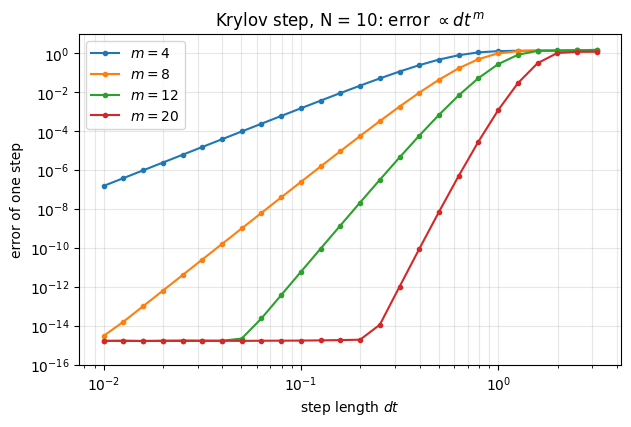

In [6]:
# ==============================================================================
# EXPERIMENT: single-step error versus dt at fixed m   (expect slope m on a log-log plot)
# ==============================================================================
dts = np.logspace(-2, 0.5, 26)
exact_dts = [exact_state(psi0_val, float(dt)) for dt in dts]
fig, ax = plt.subplots(figsize=(7, 4.3))
for col, m in zip(("C0", "C1", "C2", "C3"), (4, 8, 12, 20)):
    errs = np.array([float(jnp.linalg.norm(krylov_state_nested(bases[name0], m, dt) - ex)) for dt, ex in zip(dts, exact_dts)])
    ax.loglog(dts, errs, "o-", ms=3, color=col, label=f"$m={m}$")
    good = (errs > 1e-12) & (errs < 1e-3)
    if good.sum() >= 3:
        slope = np.polyfit(np.log(dts[good]), np.log(errs[good]), 1)[0]
        print(f"m = {m:2d}: fitted slope of log(error) vs log(dt) = {slope:5.2f}   (theory: m = {m})")
ax.set_ylim(1e-16, 10); ax.set_xlabel("step length $dt$"); ax.set_ylabel("error of one step")
ax.set_title(f"Krylov step, N = {N_val}: error $\\propto dt^{{\\,m}}$"); ax.legend(); ax.grid(alpha=0.3, which="both")
plt.show()

**Interpretation.** On the log–log plot the one-step error is a straight line of slope $\approx m$ until it hits the rounding floor: property (a) of §2.4. Compare with TEBD, whose one-step error has slope 2, 3 or 5: with $m=12$, halving the step reduces the error by $2^{12}=4096$.
This is why Krylov steps can be so much longer than Trotter steps.

## 5. How wrong are we? An a-posteriori error bound and adaptive steps

### 5.1 Derivation

Insert the Krylov state (2) into the Schrödinger equation and see what is left over — the **residual**. With $c(t)=\|\psi\|e^{-iT_mt}e_1$ and the Lanczos relation (1),

$$ |r(t)\rangle\equiv\big(i\partial_t-H\big)V_mc(t)=V_mT_mc-HV_mc=-\beta_m\,|v_{m+1}\rangle\;\big[e_m^{T}c(t)\big] . $$

The residual points along the *next* Lanczos vector, and its size is $\beta_m$ times the amplitude $c_m(t)$ on the **last** basis vector: the approximation fails when the wave packet, which starts on site 1 of the
"Lanczos chain" $T_m$ and hops along it, arrives at the end of the chain. The error $|e(t)\rangle=|\psi_m(t)\rangle-|\psi(t)\rangle$ obeys $i\partial_t|e\rangle=H|e\rangle+|r\rangle$ with $|e(0)\rangle=0$, which is solved by Duhamel's formula (variation of constants):
$|e(t)\rangle=-i\int_0^te^{-iH(t-s)}|r(s)\rangle\,ds$. Since $e^{-iH(t-s)}$ is unitary,

$$ \boxed{\;\big\|\psi_m(t)-\psi(t)\big\|\;\le\;\beta_m\int_0^t\big|c_m(s)\big|\,ds\;},\qquad c_m(s)=\|\psi\|\,\big[e^{-iT_ms}\big]_{m1} . \qquad (3)$$

Everything on the right-hand side is known from the *small* matrix: the bound costs $\mathcal O(m^2)$ per evaluation point and no additional application of $H$. For short times $c_m(s)\approx(-is)^{m-1}\beta_1\cdots\beta_{m-1}/(m-1)!$, so the bound behaves as
$t^{m}\,\beta_1\cdots\beta_m/m!$ — the $\mathcal O(t^m)$ law of §4.3 — and the integral is $\approx t\,|c_m(t)|/m$, giving the cheaper *estimate* $\;\varepsilon_{\rm est}=\beta_m|c_m(t)|\,t/m$.
Keep the two apart: (3) is a **bound**, valid for every $t$; $\varepsilon_{\rm est}$ is an **estimate**, valid while the leading term dominates. Up to the factor $1/m$, $\varepsilon_{\rm est}$ is the classical stopping criterion of Saad (1992) and the local error estimate on which the step-size controller of Expokit (Sidje 1998) is built.
The same quantity $\beta_m$ that measured the convergence of a Ritz pair for free in [Hamiltonians and ground states](11_hamiltonians_and_ground_states.ipynb) measures the accuracy of the propagator for free here: in both cases it is the single number in the Lanczos relation (1) that quantifies how far $H$ pushes the state out of the subspace.

**From formula to code.** In the eigenbasis of $T_m$, $c_m(s)=\sum_jS_{m-1,j}\,e^{-i\theta_js}\,S_{0,j}$: for a whole grid of $s$ values this is one einsum `"j,sj,j->s"`. The integral is a cumulative trapezoidal sum, which yields the bound for *every* $t$ on the grid at once.

m = 10: bound / true error in the range where the error exceeds 1e-11:  min 1.04, max 3.28


m = 20: bound / true error in the range where the error exceeds 1e-11:  min 1.04, max 3.13


m = 30: bound / true error in the range where the error exceeds 1e-11:  min 1.04, max 2.27


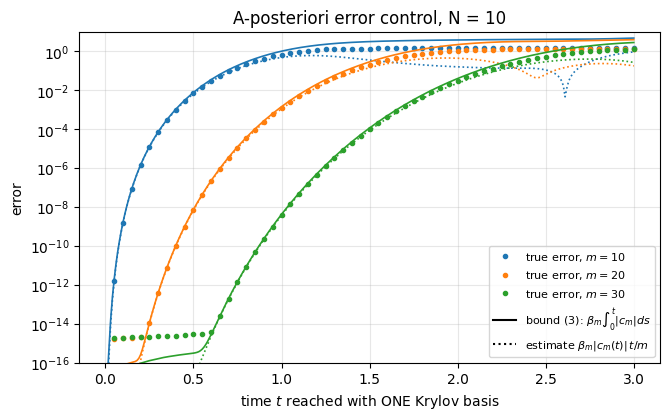

In [7]:
# ==============================================================================
# STEP 3: a-posteriori error bound, Eq. (3), on a grid of times -- from the small matrix only
# ==============================================================================
def krylov_error_bound(alphas, betas, s_grid, norm_psi=1.0):
    """Cumulative bound  B(s) = beta_m * int_0^s |c_m(s')| ds'   on the grid s_grid (s_grid[0] = 0).

    MATH   c_m(s) = ||psi|| [exp(-i T_m s)]_{m,1} = ||psi|| sum_j S[m-1,j] exp(-i theta_j s) S[0,j]        [Eq. (3)]
    COST   O(m^3) + O(m * len(s_grid)); NO application of H.
    """
    theta, S = jnp.linalg.eigh(tridiagonal(alphas, betas))
    c_last = norm_psi * jnp.abs(jnp.einsum("j,sj,j->s", S[-1, :], jnp.exp(-1j * s_grid[:, None] * theta[None, :]), S[0, :]))
    increments = 0.5 * (c_last[1:] + c_last[:-1]) * jnp.diff(s_grid)               # trapezoidal rule
    return betas[-1] * jnp.concatenate([jnp.zeros(1, dtype=RDTYPE), jnp.cumsum(increments)]), c_last


# ------------------------------------------------------------------------------
# CHECKPOINT: bound and cheap estimate versus the TRUE error (dense reference)
# ------------------------------------------------------------------------------
s_grid = jnp.linspace(0.0, 3.0, 301, dtype=RDTYPE)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
for col, m in zip(("C0", "C1", "C2"), (10, 20, 30)):
    al, be, Vm = (jnp.asarray(x[:m]) for x in bases[name0])                        # nested: first m Lanczos vectors; be[-1] = beta_m
    bound, c_last = krylov_error_bound(al, be, s_grid)
    estimate = be[-1] * c_last * s_grid / m
    # true error at a subset of times: re-use the SAME basis, only the small exponential changes with t
    idx = np.arange(5, 301, 5)
    true_err = np.array([float(jnp.linalg.norm((krylov_coefficients(al, be, s_grid[i]) @ Vm).reshape(psi0_val.shape)
                                               - exact_state(psi0_val, float(s_grid[i])))) for i in idx])
    ax.semilogy(np.asarray(s_grid)[idx], true_err, "o", ms=3, color=col, label=f"true error, $m={m}$")
    ax.semilogy(s_grid, bound + 1e-300, "-", color=col, lw=1.2)
    ax.semilogy(s_grid, estimate + 1e-300, ":", color=col, lw=1.2)
    ratio = np.asarray(bound)[idx] / true_err
    sel = true_err > 1e-11
    print(f"m = {m:2d}: bound / true error in the range where the error exceeds 1e-11:  min {ratio[sel].min():.2f}, max {ratio[sel].max():.2f}")
    assert ratio[sel].min() > 0.99                                                   # it IS a bound
ax.plot([], [], "k-", label=r"bound (3): $\beta_m\int_0^t|c_m|ds$"); ax.plot([], [], "k:", label=r"estimate $\beta_m|c_m(t)|\,t/m$")
ax.set_ylim(1e-16, 10); ax.set_xlabel("time $t$ reached with ONE Krylov basis"); ax.set_ylabel("error")
ax.set_title(f"A-posteriori error control, N = {N_val}"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()

**Interpretation.** The bound (solid) sits just above the true error (dots) over fifteen orders of magnitude — it over-estimates by a factor between 1 and about 3 only — and never fails. The cheap estimate (dotted) coincides with it while the error is small and becomes unreliable (it oscillates
and may *under*-estimate) once the error is $\mathcal O(1)$: by then the wave packet on the Lanczos chain has been reflected from the end. Because the bound is monotonic in $t$, it is the safer quantity for automatic control.

> **Numerical practice.** An error bound that is computed from the same data as the approximation itself, at negligible cost, is a luxury few algorithms offer. TEBD has nothing comparable (one has to repeat the run with a smaller step); Chebyshev has an *a-priori* estimate (the first omitted Bessel coefficient), which requires the spectral bounds to be right.

### 5.2 Adaptive time stepping

The basis $V_m$ and $T_m$ **do not depend on $dt$**. After building them we may ask the small matrix: *how far can I go with this basis before the bound exceeds my tolerance?* That is a one-dimensional search on a grid — no further applications of $H$.
The algorithm, to reach a final time $T$ with total error $\le$ `tol`:

1. build the $m$-dimensional basis from the current state;
2. evaluate the bound $B(s)$ on a grid $s\in[0,T-t]$ and take the largest $s$ for which $B(s)\le\texttt{tol}\cdot s/T$ (each step may use up its *proportional share* of the error budget). Errors committed in different steps are propagated by the exact, unitary $e^{-iH\tau}$ of the later steps, so they add at worst in norm: the total error is bounded by the sum of the per-step bounds, which is $\le\texttt{tol}\sum_ks_k/T=\texttt{tol}$;
3. advance by that $s$ with Eq. (2); repeat until $t=T$.

The number of steps now depends on the *data*. A Python `while` loop cannot be jit-compiled with a traced condition; the JAX primitive for this is `lax.while_loop(cond_fun, body_fun, init)`, which keeps iterating `body_fun` on a carry while `cond_fun(carry)` is true — all inside the compiled program.
(Its limitation: it cannot stack per-iteration outputs like `scan`, and it cannot be differentiated in reverse mode; neither matters here.)

In [8]:
# ==============================================================================
# STEP 4: adaptive Krylov propagation to a final time T with a prescribed error budget
# ==============================================================================
def krylov_adaptive_evolve(matvec, psi0, T, m, tol, n_grid=256):
    """Evolve to time T by Krylov steps of dimension m whose lengths are chosen from the error bound (3).
    Returns (psi(T), number of steps, accumulated error bound).

    ALGORITHM   per step: Lanczos basis -> bound B(s) on a grid s in [0, T-t] -> largest s with B(s) <= tol * s / T.
                (if even the first grid point violates the budget, that smallest step is taken anyway -> the returned
                accumulated bound tells the truth about what was achieved.)
    JAX         lax.while_loop: the number of steps is data dependent; carry = (psi, t, n_steps, accumulated bound).
    COST        n_steps * m applications of H.
    """
    fractions = jnp.arange(n_grid + 1, dtype=RDTYPE) / n_grid

    def not_done(carry):
        _, t, _, _ = carry
        return t < T * (1 - 1e-12)

    def one_step(carry):
        psi, t, n, acc = carry
        alphas, betas, V = lanczos_basis(matvec, psi, m)
        nrm = jnp.linalg.norm(psi)
        s_grid = (T - t) * fractions                                       # candidate step lengths (up to "finish now")
        bound, _ = krylov_error_bound(alphas, betas, s_grid, nrm)
        within_budget = bound <= tol * s_grid / T
        first_bad = jnp.where(jnp.all(within_budget), n_grid + 1, jnp.argmin(within_budget))
        i = jnp.maximum(first_bad - 1, 1)                                  # last grid point before the budget is exceeded
        c = krylov_coefficients(alphas, betas, s_grid[i])
        return nrm * (c @ V).reshape(psi.shape), t + s_grid[i], n + 1, acc + bound[i]

    psi, _, n_steps, acc = lax.while_loop(not_done, one_step, (psi0, jnp.zeros((), RDTYPE), 0, jnp.zeros((), RDTYPE)))
    return psi, n_steps, acc


krylov_adaptive_jit = jax.jit(krylov_adaptive_evolve, static_argnums=(0, 3, 5))

# ------------------------------------------------------------------------------
# CHECKPOINT: does the controller deliver what it promises?   (N = 10, T = 5, dense reference)
# ------------------------------------------------------------------------------
T_chk = 5.0
psi_exact_T = exact_state(psi0_val, T_chk)
print("  m  |   tol   | steps | H applications | true error | accumulated bound | bound respected, error <= tol")
for m in (12, 30):
    for tol in (1e-3, 1e-6, 1e-9, 1e-12):
        psi_a, n_a, bound_a = krylov_adaptive_jit(matvec_val, psi0_val, T_chk, m, tol)
        err_a = float(jnp.linalg.norm(psi_a - psi_exact_T))
        ok = (err_a <= 1.05 * float(bound_a) + 1e-13) and (err_a <= tol + 1e-13)
        print(f" {m:3d} | {tol:7.0e} | {int(n_a):5d} | {int(n_a) * m:14d} | {err_a:10.2e} | {float(bound_a):17.2e} | {ok}")
        assert ok

  m  |   tol   | steps | H applications | true error | accumulated bound | bound respected, error <= tol


  12 |   1e-03 |    13 |            156 |   7.43e-04 |          8.63e-04 | True


  12 |   1e-06 |    25 |            300 |   7.19e-07 |          7.55e-07 | True


  12 |   1e-09 |    48 |            576 |   6.00e-10 |          6.60e-10 | True


  12 |   1e-12 |    96 |           1152 |   4.08e-13 |          5.11e-13 | True


  30 |   1e-03 |     4 |            120 |   6.88e-04 |          8.59e-04 | True


  30 |   1e-06 |     5 |            150 |   7.26e-07 |          7.81e-07 | True


  30 |   1e-09 |     6 |            180 |   7.31e-10 |          7.68e-10 | True


  30 |   1e-12 |     8 |            240 |   7.31e-13 |          7.64e-13 | True


**Interpretation.** For every subspace dimension and tolerance the controller lands *just below* the requested error — the bound is tight enough that almost nothing of the budget is wasted — with no knowledge of the spectrum, no trial and error, and no reference solution.
The table also shows the trade-off in $m$: small subspaces need many short steps, larger ones need far fewer applications of $H$ but more memory and re-orthogonalisation work.
For comparison, a single Chebyshev step to $T=5$ at machine precision costs 129 applications of $H$ (measured in §8): at very high accuracy and long times Chebyshev is the more economical of the two; Krylov's restart overhead is larger than Chebyshev's.

## 6. The exact dense reference and what it costs

All validation in this course rests on the dense solution: diagonalise $H=V\,\mathrm{diag}(E)\,V^\dagger$ once, then $|\psi(t)\rangle=V\big(e^{-iEt}\odot V^\dagger|\psi(0)\rangle\big)$ for *any* $t$ — no time-step error, and arbitrarily long times at no extra cost.
Its price: the matrix has $4^N$ entries ($16\cdot4^N$ bytes; together with the eigenvectors and work space about three times that) and the diagonalisation takes $\mathcal O\big((2^N)^3\big)=\mathcal O(8^N)$ operations: **each additional spin multiplies the time by 8 and the memory by 4.**
Let us measure it (the engine's `exact_evolve` does exactly this: `dense_hamiltonian` via `vmap` over basis vectors, then `eigh`).

In [9]:
# ==============================================================================
# BENCHMARK: cost of the exact dense propagation versus N
# ==============================================================================
def timed(f, *args, repeats=2):
    """Returns (time of first call [incl. compilation], best time of `repeats` later calls, result).
    jax.block_until_ready: JAX dispatches asynchronously -- without it we would time the dispatch, not the work."""
    t0 = time.perf_counter(); out = jax.block_until_ready(f(*args)); t_first = time.perf_counter() - t0
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter(); out = jax.block_until_ready(f(*args)); best = min(best, time.perf_counter() - t0)
    return t_first, best, out


# NOTE on honest timing: the FIRST call at every N also traces and compiles the einsums and the `eigh` kernel for that
# array shape, which at small N costs far more than the linear algebra itself.  We therefore report the warm time
# (`timed` above: first call separately, then the best of two repeats) -- only that number follows the 8^N law.
exact_times, exact_first = {}, {}
print("  N | matrix size | memory of H [MB] | first call (incl. compile) [s] | warm exact_evolve [s]")
for N in (4, 6, 8, 9, 10, 11):
    terms_N, psi0_N = model_terms(N), zero_state(N)
    reps = 5 if N <= 9 else (3 if N == 10 else 2)                                    # best-of-k; cheap where the run is cheap
    t_first, t_ex, _ = timed(lambda p, t: exact_evolve(p, terms_N, t), psi0_N, 1.0, repeats=reps)
    exact_times[N], exact_first[N] = t_ex, t_first
    print(f" {N:2d} | {2 ** N:5d}^2     | {16 * 4 ** N / 1e6:16.1f} | {t_first:30.3f} | {t_ex:21.4f}")
print("\nratios of the warm times:  " + ",  ".join(
    f"N={b}/N={a}: {exact_times[b] / exact_times[a]:.1f}" for a, b in ((8, 9), (9, 10), (10, 11)))
      + f"   (asymptotic theory: 8 per spin);  overall N=8 -> 11: {exact_times[11] / exact_times[8]:.0f}x")
print(f"Extrapolation from N=11 with a factor 8 per spin (an ESTIMATE, not a measurement): "
      f"N=14: {exact_times[11] * 8 ** 3 / 60:.0f} min and {16 * 4 ** 14 / 1e9:.1f} GB per matrix;  "
      f"N=16: {exact_times[11] * 8 ** 5 / 3600:.0f} h and {16 * 4 ** 16 / 1e9:.0f} GB per matrix.")

  N | matrix size | memory of H [MB] | first call (incl. compile) [s] | warm exact_evolve [s]


  4 |    16^2     |              0.0 |                          1.889 |                0.0150


  6 |    64^2     |              0.1 |                          2.762 |                0.0965


  8 |   256^2     |              1.0 |                         15.205 |                7.0385


  9 |   512^2     |              4.2 |                         13.529 |               20.8164


 10 |  1024^2     |             16.8 |                         31.216 |               34.7390


 11 |  2048^2     |             67.1 |                         96.888 |               80.9415

ratios of the warm times:  N=9/N=8: 3.0,  N=10/N=9: 1.7,  N=11/N=10: 2.3   (asymptotic theory: 8 per spin);  overall N=8 -> 11: 11x
Extrapolation from N=11 with a factor 8 per spin (an ESTIMATE, not a measurement): N=14: 691 min and 4.3 GB per matrix;  N=16: 737 h and 69 GB per matrix.


**Interpretation.** Read the last column. Up to $N\approx8$ the dense route takes a few tens of milliseconds and up to $N\approx10$ well under a second (and is the most convenient method there is) — at those sizes what you actually wait for is the *compilation*,
which is the difference between the middle and the last column: a fraction of a second to a few seconds, almost independent of $N$. Then the $8^N$ wall rises: three more spins cost a factor of more than a hundred (the asymptotic $8^3=512$ is reached only once the diagonalisation dominates completely). The printed ratios per spin approach 8 only once the
$\mathcal O\big((2^N)^3\big)$ diagonalisation dominates over the cheaper $\mathcal O(N4^N)$ construction of the matrix; at these sizes they scatter by a factor of a few in either direction, because wall times on a shared machine do (the memory
column, which is arithmetic, does not). The extrapolation in the last line — an *estimate*, not a measurement — shows why nobody diagonalises beyond
$N\approx14$–$16$ without exploiting symmetries. The matrix-free integrators below need $\mathcal O(2^N)$ memory and, for a fixed evolution time, $\mathcal O(N^{1\text{–}2}2^N)$ operations.

## 7. Physics interlude: the Loschmidt echo — a hard exam for integrators

Before the systematic benchmark, let us see what integrator errors *do* to a physical observable. Prepare $|\psi_0\rangle=|0\dots0\rangle$ (all spins up), switch on $H$ suddenly (a *quench*) and ask: what is the probability to find the system back in its initial state?

$$ \mathcal L(t)=\big|\langle\psi_0|e^{-iHt}|\psi_0\rangle\big|^2 . $$

This **Loschmidt echo** (return probability) is the central quantity of *dynamical quantum phase transitions* — its rate function $-\tfrac1N\ln\mathcal L(t)$ stays finite as $N\to\infty$ and can become non-analytic in time — and it is measured in trapped-ion and cold-atom quantum simulators.
Numerically it is demanding for a simple reason: for a many-body system $\mathcal L$ becomes *exponentially small* in $N$. Write the numerical state as $|\psi\rangle+|\delta\rangle$ with $\|\delta\|=\varepsilon$ and the exact amplitude as $A=\langle\psi_0|\psi\rangle$, $|A|=\sqrt{\mathcal L}$. Then

$$ \mathcal L_{\rm num}-\mathcal L=2\,\mathrm{Re}\big[\bar A\,\langle\psi_0|\delta\rangle\big]+\big|\langle\psi_0|\delta\rangle\big|^2,\qquad\text{so}\qquad \frac{\big|\mathcal L_{\rm num}-\mathcal L\big|}{\mathcal L}\;\le\;\frac{2\varepsilon}{\sqrt{\mathcal L}}+\frac{\varepsilon^2}{\mathcal L} . $$

The relative error of the echo is the relative error of the state **amplified by $1/\sqrt{\mathcal L}$**. The bound is attained only if the error vector happens to point along $|\psi_0\rangle$; what enters is $\langle\psi_0|\delta\rangle=\eta\,\varepsilon$ with $0\le\eta\le1$, and we measure $\eta$ below.
Even so: an error of $10^{-3}$ in the state is invisible in a magnetisation curve, but it can be 100 % of an echo of $10^{-6}$.

We compute $\mathcal L(t)$ on the $N=10$ chain with every integrator at the *same* step $dt=0.05$ (TEBD orders 1, 2, 4; Krylov with a small subspace $m=8$) plus Chebyshev, recording the full state at every step so that we can also plot the state error against the dense solution.

**From formula to code.** Every trajectory is a `lax.scan` over time steps whose body applies one step and emits the flattened state; the echo is then a single matrix–vector product of the stored states with $\langle\psi_0|$. The compact Chebyshev step below is the algorithm derived in the [previous notebook](13_chebyshev_propagation.ipynb):
coefficients $c_k=(2-\delta_{k0})(-i)^kJ_k(a\,dt)$ from SciPy, the recurrence $\phi_{k+1}=2\tilde H\phi_k-\phi_{k-1}$ as an inner `scan`.

In [10]:
# ==============================================================================
# STEP 5: uniform "step" interface for all integrators + trajectories with lax.scan
# ==============================================================================
def make_tebd_step(terms, dt, order):
    """One Trotter-Suzuki step of the given order as a function psi -> psi (gates pre-computed for this dt)."""
    gates = tebd_gates(terms, dt, order)
    return lambda psi: apply_gates(psi, gates)


def make_chebyshev_step(terms, bounds, dt, tol=1e-13, safety=1.02):
    """exp(-i H dt) by the Chebyshev/Jacobi-Anger expansion (derived in the previous notebook).  Returns (step, K).
    MATH   H~ = (H - b)/a in [-1,1];   exp(-iH dt) = e^{-i b dt} sum_k c_k T_k(H~),  c_k = (2-delta_k0)(-i)^k J_k(a dt),
           truncated after the last |J_k(a dt)| >= tol;  T_{k+1} = 2 H~ T_k - T_{k-1}  as a lax.scan."""
    a, b = safety * (bounds[1] - bounds[0]) / 2.0, (bounds[1] + bounds[0]) / 2.0
    z = a * dt
    J = jv(np.arange(int(abs(z) + 12 * abs(z) ** (1 / 3) + 40)), z)
    K = max(1, int(np.max(np.nonzero(np.abs(J) >= tol)[0], initial=1)))
    k = np.arange(K + 1)
    coef = jnp.asarray(np.where(k == 0, 1.0, 2.0) * (-1j) ** k * J[:K + 1], dtype=CDTYPE)
    phase = jnp.asarray(np.exp(-1j * b * dt), dtype=CDTYPE)

    def Ht(phi):
        return (apply_hamiltonian(terms, phi) - b * phi) / a

    def step(psi):
        phi_prev, phi_curr = psi, Ht(psi)
        acc = coef[0] * phi_prev + coef[1] * phi_curr

        def body(carry, c_k):
            p_prev, p_curr, acc = carry
            p_next = 2 * Ht(p_curr) - p_prev
            return (p_curr, p_next, acc + c_k * p_next), None

        (_, _, acc), _ = lax.scan(body, (phi_prev, phi_curr, acc), coef[2:])
        return phase * acc

    return step, K


def trajectory(step, psi0, n_steps):
    """Apply `step` n_steps times, returning all intermediate states as an array (n_steps, 2^N).  One jitted scan."""
    def body(psi, _):
        psi = step(psi)
        return psi, psi.reshape(-1)
    return jax.jit(lambda p: lax.scan(body, p, None, length=n_steps)[1])(psi0)


# ==============================================================================
# PARAMETERS of the echo experiment
# ==============================================================================
T_echo, dt_echo = 5.0, 0.05
n_echo = int(round(T_echo / dt_echo))
times_echo = dt_echo * np.arange(1, n_echo + 1)
bounds_val = spectral_bounds(terms_val, N_val)                        # short Lanczos run (for Chebyshev only)

steppers = {"TEBD-1": make_tebd_step(terms_val, dt_echo, 1),
            "TEBD-2": make_tebd_step(terms_val, dt_echo, 2),
            "TEBD-4": make_tebd_step(terms_val, dt_echo, 4),
            "Krylov m=8": lambda psi: krylov_step(matvec_val, psi, dt_echo, 8),
            "Chebyshev": make_chebyshev_step(terms_val, bounds_val, dt_echo)[0]}

amp0 = V_d.conj().T @ psi0_val.reshape(-1)
states_exact = (V_d @ (jnp.exp(-1j * E_d[:, None] * jnp.asarray(times_echo)[None, :]) * amp0[:, None])).T      # (n_times, 2^N)
echo_exact = np.abs(np.asarray(states_exact @ psi0_val.reshape(-1).conj())) ** 2

E_psi0 = float(jnp.real(jnp.vdot(psi0_val, matvec_val(psi0_val))))          # the conserved energy of the initial state

echo, state_err = {}, {}
for name, stp in steppers.items():
    traj = trajectory(stp, psi0_val, n_echo)
    echo[name] = np.abs(np.asarray(traj @ psi0_val.reshape(-1).conj())) ** 2
    state_err[name] = np.asarray(jnp.linalg.norm(traj - states_exact, axis=1))
    rel = np.abs(echo[name] - echo_exact) / echo_exact
    i_rel = int(np.argmax(rel))
    # how the state error grows with time, and how much of it points along |psi0> (the factor eta of the introduction)
    late = times_echo >= 1.0
    slope = np.polyfit(np.log(times_echo[late]), np.log(state_err[name][late] + 1e-300), 1)[0]
    delta = np.asarray(traj - states_exact)
    eta = np.abs(delta @ np.asarray(psi0_val).reshape(-1).conj()) / (state_err[name] + 1e-300)
    # conserved quantities: norm (all schemes) and energy (Krylov by construction -- section 2.4)
    traj_np = np.asarray(traj)
    energy_t = np.real(np.einsum("ni,ij,nj->n", traj_np.conj(), np.asarray(H_dense), traj_np))
    print(f"{name:11s}: state error at T = {state_err[name][-1]:.2e} (growing as t^{slope:.2f});   max_t |L - L_exact| = {np.max(np.abs(echo[name] - echo_exact)):.2e};"
          f"   max_t | ||psi|| - 1 | = {float(jnp.max(jnp.abs(jnp.linalg.norm(traj, axis=1) - 1))):.1e};"
          f"   max_t |<H> - <H>(0)| = {np.max(np.abs(energy_t - E_psi0)):.2e}")
    print(f"{'':11s}  worst RELATIVE echo error {rel[i_rel]:.2e} at t = {times_echo[i_rel]:.2f} (where L = {echo_exact[i_rel]:.1e}); "
          f"state error there {state_err[name][i_rel]:.2e}  ->  ratio {rel[i_rel] / state_err[name][i_rel]:.1f}"
          f"   (worst case 2/sqrt(L) = {2 / np.sqrt(echo_exact[i_rel]):.0f}, realised because eta = {eta[i_rel]:.3f})")
print(f"smallest value of the exact echo on the grid: {echo_exact.min():.3e}")
assert state_err["Chebyshev"].max() < 100 * TOL

TEBD-1     : state error at T = 2.86e-01 (growing as t^1.01);   max_t |L - L_exact| = 7.01e-04;   max_t | ||psi|| - 1 | = 2.4e-13;   max_t |<H> - <H>(0)| = 2.20e-01
             worst RELATIVE echo error 1.86e-01 at t = 4.65 (where L = 4.9e-04); state error there 2.68e-01  ->  ratio 0.7   (worst case 2/sqrt(L) = 90, realised because eta = 0.008)


TEBD-2     : state error at T = 1.14e-02 (growing as t^0.97);   max_t |L - L_exact| = 3.77e-04;   max_t | ||psi|| - 1 | = 1.4e-13;   max_t |<H> - <H>(0)| = 1.45e-02
             worst RELATIVE echo error 1.80e-02 at t = 1.90 (where L = 2.4e-04); state error there 3.56e-03  ->  ratio 5.1   (worst case 2/sqrt(L) = 130, realised because eta = 0.039)


TEBD-4     : state error at T = 1.99e-06 (growing as t^0.78);   max_t |L - L_exact| = 1.07e-07;   max_t | ||psi|| - 1 | = 2.7e-12;   max_t |<H> - <H>(0)| = 2.92e-06
             worst RELATIVE echo error 6.23e-06 at t = 4.60 (where L = 1.1e-03); state error there 1.84e-06  ->  ratio 3.4   (worst case 2/sqrt(L) = 61, realised because eta = 0.076)


Krylov m=8 : state error at T = 1.02e-07 (growing as t^1.00);   max_t |L - L_exact| = 3.02e-09;   max_t | ||psi|| - 1 | = 8.4e-15;   max_t |<H> - <H>(0)| = 6.13e-14
             worst RELATIVE echo error 6.49e-07 at t = 1.80 (where L = 2.8e-04); state error there 3.68e-08  ->  ratio 17.6   (worst case 2/sqrt(L) = 121, realised because eta = 0.159)


Chebyshev  : state error at T = 5.23e-13 (growing as t^1.00);   max_t |L - L_exact| = 3.16e-14;   max_t | ||psi|| - 1 | = 5.9e-15;   max_t |<H> - <H>(0)| = 1.61e-13
             worst RELATIVE echo error 6.72e-12 at t = 4.65 (where L = 4.9e-04); state error there 4.86e-13  ->  ratio 13.8   (worst case 2/sqrt(L) = 90, realised because eta = 0.156)
smallest value of the exact echo on the grid: 2.313e-04


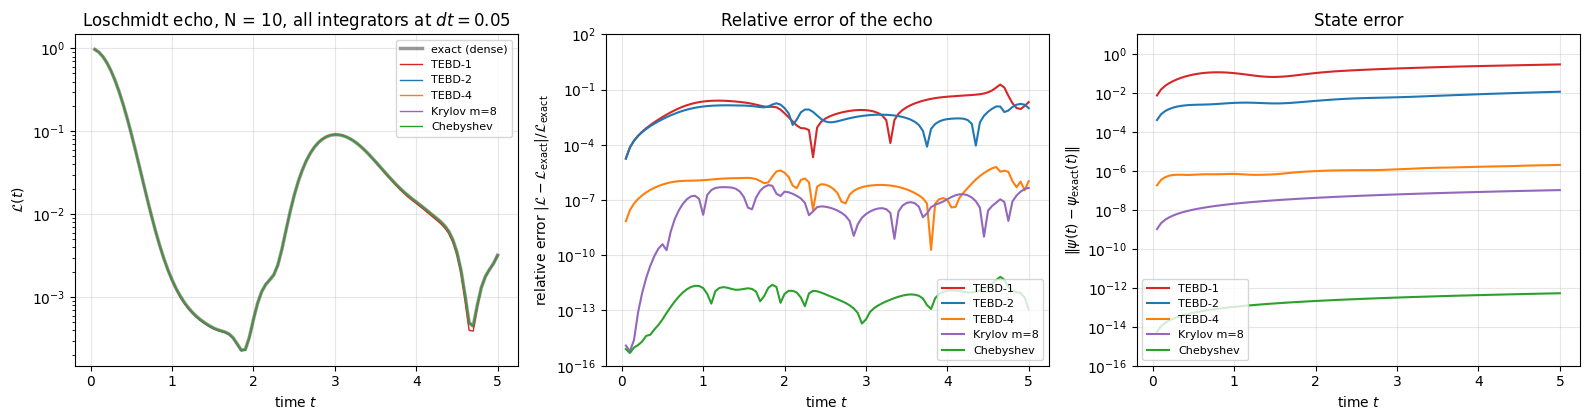

In [11]:
# ==============================================================================
# FIGURE: Loschmidt echo and state error for all integrators at the same step dt = 0.05
# ==============================================================================
colors = {"TEBD-1": "C3", "TEBD-2": "C0", "TEBD-4": "C1", "Krylov m=8": "C4", "Chebyshev": "C2"}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
axes[0].semilogy(times_echo, echo_exact, "k-", lw=2.5, alpha=0.4, label="exact (dense)")
for name in steppers:
    axes[0].semilogy(times_echo, echo[name], "-", lw=1, color=colors[name], label=name)
    axes[1].semilogy(times_echo, np.abs(echo[name] - echo_exact) / echo_exact + 1e-300, "-", color=colors[name], label=name)
    axes[2].semilogy(times_echo, state_err[name] + 1e-300, "-", color=colors[name], label=name)
axes[0].set_ylabel(r"$\mathcal{L}(t)$"); axes[0].set_title(f"Loschmidt echo, N = {N_val}, all integrators at $dt={dt_echo}$")
axes[1].set_ylabel(r"relative error $|\mathcal{L}-\mathcal{L}_{\rm exact}|/\mathcal{L}_{\rm exact}$"); axes[1].set_title("Relative error of the echo"); axes[1].set_ylim(1e-16, 1e2)
axes[2].set_ylabel(r"$\|\psi(t)-\psi_{\rm exact}(t)\|$"); axes[2].set_title("State error"); axes[2].set_ylim(1e-16, 1e1)
for ax in axes:
    ax.set_xlabel("time $t$"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation.**

* *Left.* The echo drops by several orders of magnitude within a time of order one and then fluctuates at a small value set by the (large but finite) number of eigenstates involved. On this scale first-order TEBD is visibly wrong — not just inaccurate at the minima, where the true echo is small, but
  everywhere at late times; the other curves look fine to the eye.
* *Middle and right.* The error panels reveal the hierarchy. The state errors settle at $\sim10^{-1}$ (TEBD-1), $\sim10^{-2}$ (TEBD-2) and $\sim10^{-6}$ (TEBD-4) for this $dt$; Krylov with a mere $m=8$ vectors
  sits at $10^{-7}$ and Chebyshev at $10^{-13}$ — for them $dt=0.05$ is a tiny step. All of them grow **linearly in time** after an initial transient: the fitted exponents printed above are $1.0$ for every scheme except fourth-order TEBD ($0.8$).
  Linear growth is what one expects when the same error operator is committed at every step and the individual contributions add up without cancelling.
* The *relative* error of the echo (middle) is not a constant multiple of the state error: it peaks exactly where the echo dips, at the minima of $\mathcal L$ around $t\approx1.9$ and $t\approx4.7$, as the printed ratio
  "relative echo error / state error at the same time" shows — between 3 and 18 for every scheme except first-order TEBD, whose state error is of order one, so that the linearised argument above no longer applies to it at all.
  These ratios are well below the worst case $2/\sqrt{\mathcal L}\approx60$–$130$ printed next to them, and the reason is in the same column: the overlap fraction $\eta=|\langle\psi_0|\delta\rangle|/\|\delta\|$ is only $0.04$–$0.16$, so most of the error vector is invisible to *this* observable.
  Do not count on that: $\eta$ is a property of the particular integrator, state and time, and the ratio is $2\eta/\sqrt{\mathcal L}$ with $\eta\le1$ the only guarantee.
  On this grid $\mathcal L$ never falls below $\sim2\times10^{-4}$, so the amplification stays modest; push $N$ or $T$ up, let $\mathcal L$ reach $10^{-8}$, and
  the factor $1/\sqrt{\mathcal L}$ of the introduction turns a state error of $10^{-3}$ into a meaningless echo.
* *The conserved quantities say nothing.* Every integrator conserves the norm to rounding accuracy (printed above), including the one whose state is wrong by 30 %. The energy column makes the pitfall of §2.4 concrete from the other side:
  Krylov with $m=8$ holds $\langle H\rangle$ to $6\times10^{-14}$ while its state is wrong by $10^{-7}$, and Chebyshev holds it to $1.6\times10^{-13}$ while being right to $5\times10^{-13}$ — the same diagnostic, opposite information. TEBD, which conserves the norm but not the energy,
  drifts by $1.5\times10^{-2}$ (order 2) and $2.9\times10^{-6}$ (order 4), that is by about its own state error: for a Trotter scheme the energy drift *is* a useful diagnostic, for a Krylov scheme it is not.

> **Physics insight.** Whether an integrator is "accurate enough" depends on the observable. Local observables of a generic (non-integrable) chain are forgiving: a slightly wrong state has nearly the same local expectation values. Overlaps (echoes, fidelities, fidelity susceptibilities, out-of-time-order correlators built from
> forward and backward evolution) are unforgiving, because they are sensitive to the global phase relationships of all $2^N$ amplitudes.

## 8. Head-to-head I: work–precision diagram at fixed $N$

### 8.1 Rules of the game

* **Task:** $|0\dots0\rangle\to e^{-iHT}|0\dots0\rangle$, $T=5$, $N=10$, the model of §3. **Error:** $\|\psi-\psi_{\rm exact}\|$ against the dense solution — the most demanding measure, including the global phase.
* **Contestants:** TEBD of order 1, 2, 4 for a range of $dt$; Chebyshev in one step for a range of tolerances; adaptive Krylov with $m=12$ and $m=30$ for a range of tolerances.
* **Timing:** every integrator is compiled into one XLA program; we report the *first call* (dominated by compilation) separately from the *best of three* subsequent calls, with `block_until_ready`.
  To keep compilation out of the $dt$-scan, the TEBD programs take the gate matrices and the number of steps as *traced arguments* (the loop is a `lax.fori_loop`, which accepts a traced trip count), so one compilation per order serves every $dt$.
* **Work** is also counted in a machine-independent currency, *$H$-equivalents*: one application of $H$ costs one einsum per local term ($2N-1$ of them). A TEBD step of order 1 applies $2N-1$ gates (1 $H$-equivalent), order 2: two sweeps (2), order 4: five second-order steps (10).
  Chebyshev: $K$; Krylov: $m$ per step (its re-orthogonalisation is extra and shows up only in the wall time).

> **Numerical practice.** Absolute wall times depend on the hardware and on whatever else the machine is doing (this notebook was executed on a shared multi-core CPU); conclusions should be drawn from *ratios* and *slopes*, which are robust. Re-run the cell on your machine — and on a GPU, where the large-$N$ numbers change considerably.

In [12]:
# ==============================================================================
# STEP 6: the benchmark harness
# ==============================================================================
def make_tebd_runner(terms, order):
    """jit-compiled (psi, gate_matrices, n_steps) -> psi for a fixed gate LAYOUT; matrices and n_steps are traced,
    so a single compilation serves every dt.  Returns (runner, number of gates per step)."""
    layout = [q for q, _ in tebd_gates(terms, 0.1, order)]

    @jax.jit
    def run(psi, mats, n_steps):
        def one_step(_, p):
            for q, U in zip(layout, mats):
                p = apply_gate(p, U, q)
            return p
        return lax.fori_loop(0, n_steps, one_step, psi)

    return run, len(layout)


def tebd_matrices(terms, dt, order):
    return [U for _, U in tebd_gates(terms, dt, order)]


T_wp = 5.0
psi_exact_wp = exact_state(psi0_val, T_wp)
n_terms_H = len(terms_val)
records = []            # rows: (method, parameter label, H-equivalents, error, run time, first-call time)

# --- TEBD, orders 1, 2, 4
# (the grids stop where the curve is already a clean power law; the smallest first-order step below would need 5000 steps
#  and several seconds per timing repetition, for one more point on a straight line)
tebd_grid = {1: (0.02, 0.01, 0.005, 0.002), 2: (0.1, 0.05, 0.02, 0.01, 0.005), 4: (0.25, 0.1, 0.05, 0.025, 0.0125)}
for order, dts in tebd_grid.items():
    runner, n_gates = make_tebd_runner(terms_val, order)
    for i, dt in enumerate(dts):
        n_steps = int(round(T_wp / dt))
        t_first, t_run, out = timed(runner, psi0_val, tebd_matrices(terms_val, dt, order), n_steps, repeats=3)
        records.append((f"TEBD-{order}", f"dt={dt:g}", n_steps * n_gates / n_terms_H, float(jnp.linalg.norm(out - psi_exact_wp)),
                        t_run, t_first if i == 0 else np.nan))          # only the first dt of each order compiles

# --- Chebyshev, single step of length T
for tol in (1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-13):
    step, K = make_chebyshev_step(terms_val, bounds_val, T_wp, tol)
    t_first, t_run, out = timed(jax.jit(step), psi0_val, repeats=3)
    records.append(("Chebyshev", f"tol={tol:g}", K, float(jnp.linalg.norm(out - psi_exact_wp)), t_run, t_first))

# --- adaptive Krylov, two subspace sizes
for m in (12, 30):
    for i, tol in enumerate((1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12)):
        t_first, t_run, (out, n_a, _) = timed(krylov_adaptive_jit, matvec_val, psi0_val, T_wp, m, tol, repeats=3)
        records.append((f"Krylov m={m}", f"tol={tol:g}", int(n_a) * m, float(jnp.linalg.norm(out - psi_exact_wp)),
                        t_run, t_first if i == 0 else np.nan))

print(f"{'method':12s} | {'parameter':10s} | H-equiv. |   error   | run [ms] | first call incl. compile [s]")
for meth, par, work, err, t_run, t_first in records:
    print(f"{meth:12s} | {par:10s} | {work:8.0f} | {err:9.2e} | {1e3 * t_run:8.1f} | " + ("" if np.isnan(t_first) else f"{t_first:6.2f}"))

method       | parameter  | H-equiv. |   error   | run [ms] | first call incl. compile [s]
TEBD-1       | dt=0.02    |      250 |  1.16e-01 |     96.8 |   1.01
TEBD-1       | dt=0.01    |      500 |  5.83e-02 |    136.4 | 
TEBD-1       | dt=0.005   |     1000 |  2.92e-02 |    362.0 | 
TEBD-1       | dt=0.002   |     2500 |  1.17e-02 |    753.4 | 
TEBD-2       | dt=0.1     |      100 |  4.53e-02 |     31.8 |   0.93
TEBD-2       | dt=0.05    |      200 |  1.14e-02 |     49.8 | 
TEBD-2       | dt=0.02    |      500 |  1.82e-03 |    142.0 | 
TEBD-2       | dt=0.01    |     1000 |  4.55e-04 |    210.2 | 
TEBD-2       | dt=0.005   |     2000 |  1.14e-04 |    410.1 | 
TEBD-4       | dt=0.25    |      200 |  1.23e-03 |     45.7 |   1.12
TEBD-4       | dt=0.1     |      500 |  3.18e-05 |    107.6 | 
TEBD-4       | dt=0.05    |     1000 |  1.99e-06 |    216.0 | 
TEBD-4       | dt=0.025   |     2000 |  1.25e-07 |    557.4 | 
TEBD-4       | dt=0.0125  |     4000 |  7.80e-09 |   1013.2 | 
Chebyshev

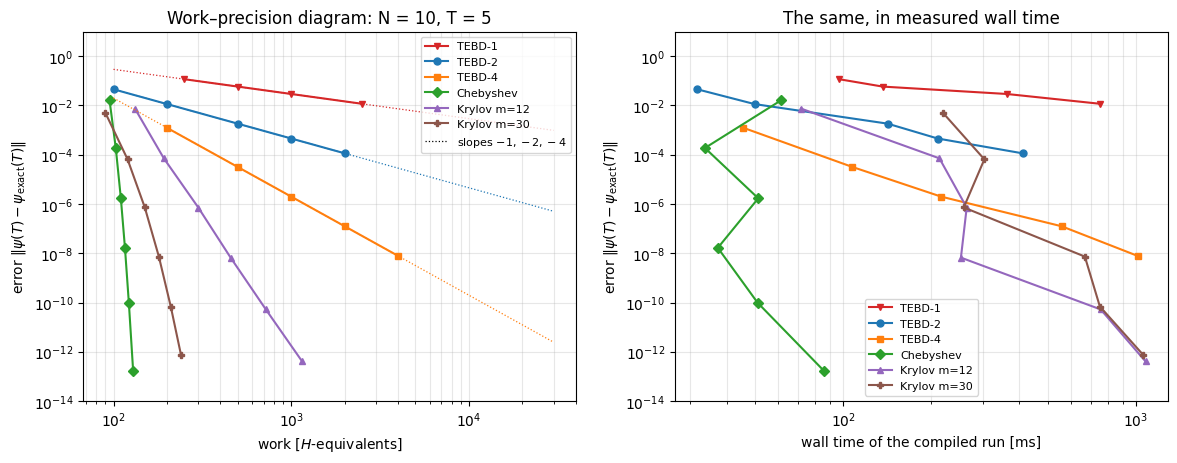

In [13]:
# ==============================================================================
# FIGURE: work-precision diagram  (left: operation count, right: measured wall time)
# ==============================================================================
style = {"TEBD-1": ("C3", "v"), "TEBD-2": ("C0", "o"), "TEBD-4": ("C1", "s"), "Chebyshev": ("C2", "D"), "Krylov m=12": ("C4", "^"), "Krylov m=30": ("C5", "P")}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for meth, (col, mk) in style.items():
    rows = [r for r in records if r[0] == meth]
    work, err, t_run = (np.array([r[i] for r in rows]) for i in (2, 3, 4))
    axes[0].loglog(work, err, mk + "-", color=col, ms=5, label=meth)
    axes[1].loglog(1e3 * t_run, err, mk + "-", color=col, ms=5, label=meth)
w = np.array([1e2, 3e4])
for meth, p in (("TEBD-1", 1), ("TEBD-2", 2), ("TEBD-4", 4)):
    r = [r for r in records if r[0] == meth][1]
    axes[0].loglog(w, r[3] * (w / r[2]) ** (-float(p)), ":", color=style[meth][0], lw=0.9)
axes[0].plot([], [], "k:", lw=0.9, label="slopes $-1,-2,-4$")
axes[0].set_xlabel("work [$H$-equivalents]"); axes[1].set_xlabel("wall time of the compiled run [ms]")
for ax in axes:
    ax.set_ylim(1e-14, 10); ax.set_ylabel(r"error $\|\psi(T)-\psi_{\rm exact}(T)\|$"); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)
axes[0].set_title(f"Work–precision diagram: N = {N_val}, T = {T_wp:g}"); axes[1].set_title("The same, in measured wall time")
plt.show()

**Interpretation.** Pick an accuracy on the vertical axis and read off the cost horizontally.

* **TEBD** follows its power laws (dotted: error $\propto$ work$^{-p}$): every digit costs a factor $10$ (order 1), $\sqrt{10}$ (order 2), $10^{1/4}$ (order 4) more work. First order is never competitive. Second order is the cheapest *Trotter*
  route to a rough answer (error $\gtrsim10^{-2}$); fourth order takes over below that and remains respectable down to $\sim10^{-6}$–$10^{-8}$. Note, though, that even at $10^{-2}$ the TEBD curves are not below the other two families —
  the polynomial methods are already at their threshold cost there.
* **Chebyshev and Krylov** have nearly vertical curves: a threshold cost of about $aT\approx90$ applications of $H$, after which additional digits are almost free. Chebyshev is the cheapest of all below $\sim10^{-4}$; Krylov with $m=30$ costs up to about twice as many $H$ applications (restart overhead: every step must again "fill" its
  subspace) and with $m=12$, whose steps are much shorter, up to nine times as many at the tightest tolerance — still far ahead of TEBD at high accuracy.
* In **wall time** Krylov pays additionally for re-orthogonalisation and for handling $m$ vectors; the ranking among the three families is unchanged.
* **Compilation** (last column of the table) costs between a fraction of a second and a second or two — comparable to, and for most entries larger than, the compiled run itself at $N=10$. At small $N$ compile time is what you wait for,
  and it matters only that we compile *once*. TEBD-4, whose step contains $10(2N-1)$ gates, is the most expensive to compile; the Krylov entries look cheap only because the identical program (same static $m$) was already
  compiled in §5.2 and comes straight from JAX's cache.

## 9. Head-to-head II: scaling with the system size at fixed accuracy

### 9.1 Protocol

The second question is how the contestants scale with $N$. We fix the task ($T=2$, the same quench) and an accuracy target of $10^{-4}$ in the state norm, a level at which TEBD is still in the game. The TEBD steps are *calibrated* on the $N=10$ chain, where the error is measured against the dense solution and the step is set from the
known error law $\varepsilon\propto dt^{p}$; the same steps are then used for all $N$ (the Trotter error grows slowly with $N$, which we monitor). Chebyshev and adaptive Krylov ($m=20$) are simply *given* the tolerance. For $N\le10$ errors are measured against the dense solution; for larger $N$, where no dense solution is affordable,
we use as reference a Chebyshev run at tolerance $10^{-13}$ — legitimate because that propagator has been validated to $\sim10^{-13}$ against exact results and its accuracy does not depend on $N$ — and we cross-check it against the independent Krylov result.
(Timing here: first call separately, then *one* timed repetition per entry — six sizes times four methods times the $N=16$ runs would otherwise cost several extra minutes. The wall times therefore carry more noise than those of §8.)

In [14]:
# ==============================================================================
# CALIBRATION of the TEBD steps on N = 10 for the target accuracy (dense reference)
# ==============================================================================
T_sc, TARGET = 2.0, 1e-4
psi_exact_sc = exact_state(psi0_val, T_sc)
dt_cal = {}
for order, dt_probe in ((2, 0.02), (4, 0.1)):
    runner, _ = make_tebd_runner(terms_val, order)
    err_probe = float(jnp.linalg.norm(runner(psi0_val, tebd_matrices(terms_val, dt_probe, order), int(round(T_sc / dt_probe))) - psi_exact_sc))
    dt_need = dt_probe * (0.7 * TARGET / err_probe) ** (1 / order)               # error ~ dt^order; 0.7 = safety margin
    n_steps = int(np.ceil(T_sc / dt_need))
    dt_cal[order] = T_sc / n_steps
    err_cal = float(jnp.linalg.norm(runner(psi0_val, tebd_matrices(terms_val, dt_cal[order], order), n_steps) - psi_exact_sc))
    print(f"TEBD-{order}: probe dt = {dt_probe} -> error {err_probe:.2e};  calibrated dt = {dt_cal[order]:.5f} ({n_steps} steps) -> error {err_cal:.2e}")
    assert err_cal < TARGET

TEBD-2: probe dt = 0.02 -> error 6.18e-04;  calibrated dt = 0.00671 (298 steps) -> error 6.96e-05


TEBD-4: probe dt = 0.1 -> error 1.55e-05;  calibrated dt = 0.14286 (14 steps) -> error 6.46e-05


In [15]:
# ==============================================================================
# BENCHMARK: wall time versus N at fixed accuracy  (compile time separated)
# ==============================================================================
M_SC = 20
SIZES = (6, 8, 10, 12, 14, 16)
scaling = []       # rows: (N, method, error, run time, first-call time)
for N in SIZES:
    terms_N, psi0_N = model_terms(N), zero_state(N)
    matvec_N = make_matvec(terms_N)
    bounds_N = spectral_bounds(terms_N, N)
    # --- reference: dense for N <= 10, else Chebyshev at tol = 1e-13
    ref_step, _ = make_chebyshev_step(terms_N, bounds_N, T_sc, 1e-13)
    psi_cheb_ref = jax.jit(ref_step)(psi0_N)
    if N <= 10:
        psi_ref = exact_evolve(psi0_N, terms_N, T_sc)
        ref_gap = float(jnp.linalg.norm(psi_cheb_ref - psi_ref))
        assert ref_gap < 100 * TOL                                          # the Chebyshev reference IS exact where we can check
    else:
        psi_ref, ref_gap = psi_cheb_ref, np.nan
    # --- contestants
    for order in (2, 4):
        runner, _ = make_tebd_runner(terms_N, order)
        t_first, t_run, out = timed(runner, psi0_N, tebd_matrices(terms_N, dt_cal[order], order), int(round(T_sc / dt_cal[order])), repeats=1)
        scaling.append((N, f"TEBD-{order}", float(jnp.linalg.norm(out - psi_ref)), t_run, t_first))
    step, K = make_chebyshev_step(terms_N, bounds_N, T_sc, TARGET)
    t_first, t_run, out = timed(jax.jit(step), psi0_N, repeats=1)
    scaling.append((N, "Chebyshev", float(jnp.linalg.norm(out - psi_ref)), t_run, t_first))
    t_first, t_run, (out, n_a, _) = timed(krylov_adaptive_jit, matvec_N, psi0_N, T_sc, M_SC, TARGET, repeats=1)
    scaling.append((N, f"Krylov m={M_SC}", float(jnp.linalg.norm(out - psi_ref)), t_run, t_first))
    # independent cross-check of the reference for large N: tight Krylov vs tight Chebyshev
    psi_kry_ref, _, _ = krylov_adaptive_jit(matvec_N, psi0_N, T_sc, M_SC, 1e-12)
    cross = float(jnp.linalg.norm(psi_kry_ref - psi_cheb_ref))
    assert cross < 1e3 * TOL
    print(f"N = {N:2d}: Chebyshev K = {K:3d}, Krylov steps = {int(n_a)};  reference check: |cheb_ref - dense| = {ref_gap:.1e}, |cheb_ref - krylov_ref| = {cross:.1e}")

print(f"\n{'N':>3s} | " + " | ".join(f"{m:^27s}" for m in ("TEBD-2", "TEBD-4", "Chebyshev", f"Krylov m={M_SC}")))
print("    | " + " | ".join(f"{'error':>8s} {'run[s]':>8s} {'first[s]':>8s} " for _ in range(4)))
for N in SIZES:
    rows = [r for r in scaling if r[0] == N]
    print(f"{N:3d} | " + " | ".join(f"{r[2]:8.1e} {r[3]:8.3f} {r[4]:8.2f} " for r in rows))

N =  6: Chebyshev K =  30, Krylov steps = 2;  reference check: |cheb_ref - dense| = 1.2e-13, |cheb_ref - krylov_ref| = 8.3e-13


N =  8: Chebyshev K =  39, Krylov steps = 2;  reference check: |cheb_ref - dense| = 4.4e-14, |cheb_ref - krylov_ref| = 7.5e-13


N = 10: Chebyshev K =  47, Krylov steps = 3;  reference check: |cheb_ref - dense| = 1.0e-13, |cheb_ref - krylov_ref| = 8.5e-13


N = 12: Chebyshev K =  55, Krylov steps = 4;  reference check: |cheb_ref - dense| = nan, |cheb_ref - krylov_ref| = 8.1e-13


N = 14: Chebyshev K =  63, Krylov steps = 4;  reference check: |cheb_ref - dense| = nan, |cheb_ref - krylov_ref| = 7.5e-13


N = 16: Chebyshev K =  71, Krylov steps = 4;  reference check: |cheb_ref - dense| = nan, |cheb_ref - krylov_ref| = 7.4e-13

  N |           TEBD-2            |           TEBD-4            |          Chebyshev          |         Krylov m=20        
    |    error   run[s] first[s]  |    error   run[s] first[s]  |    error   run[s] first[s]  |    error   run[s] first[s] 
  6 |  4.6e-05    0.017     0.54  |  4.6e-05    0.006     0.54  |  1.1e-04    0.002     0.46  |  8.2e-05    0.007     1.28 
  8 |  5.9e-05    0.055     0.63  |  5.6e-05    0.016     1.05  |  7.0e-05    0.006     1.02  |  5.1e-05    0.015     1.97 
 10 |  7.0e-05    0.145     0.74  |  6.5e-05    0.056     1.19  |  9.7e-05    0.012     0.87  |  6.5e-05    0.048     1.31 
 12 |  8.0e-05    0.549     1.45  |  7.2e-05    0.123     1.54  |  1.1e-04    0.096     1.13  |  7.7e-05    0.223     2.35 
 14 |  8.9e-05    3.253     4.07  |  8.0e-05    0.649     3.71  |  1.1e-04    0.550     1.94  |  6.1e-05    1.052     3.98 
 16 |  9

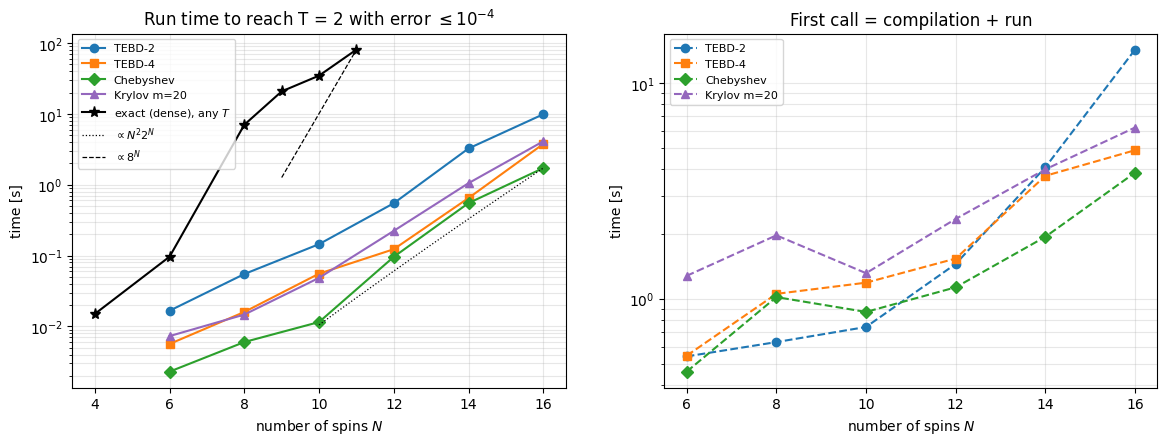

In [16]:
# ==============================================================================
# FIGURE: run time and first-call (compile) time versus N, plus the dense reference of section 6
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
style_sc = {"TEBD-2": ("C0", "o"), "TEBD-4": ("C1", "s"), "Chebyshev": ("C2", "D"), f"Krylov m={M_SC}": ("C4", "^")}
for meth, (col, mk) in style_sc.items():
    rows = [r for r in scaling if r[1] == meth]
    Ns = np.array([r[0] for r in rows])
    axes[0].semilogy(Ns, [r[3] for r in rows], mk + "-", color=col, label=meth)
    axes[1].semilogy(Ns, [r[4] for r in rows], mk + "--", color=col, label=meth)
Ns_ex = np.array(sorted(exact_times))
axes[0].semilogy(Ns_ex, [exact_times[n] for n in Ns_ex], "k*-", ms=8, label="exact (dense), any $T$")
ref_rows = [r for r in scaling if r[1] == "Chebyshev"]
N_hi, t_hi = ref_rows[-1][0], ref_rows[-1][3]
Ns_line = np.arange(10, SIZES[-1] + 1)
axes[0].semilogy(Ns_line, t_hi * (Ns_line / N_hi) ** 2 * 2.0 ** (Ns_line - N_hi), "k:", lw=0.9, label=r"$\propto N^2 2^N$")
axes[0].semilogy(Ns_ex[-3:], exact_times[Ns_ex[-1]] * 8.0 ** (Ns_ex[-3:] - Ns_ex[-1]), "k--", lw=0.9, label=r"$\propto 8^N$")
axes[0].set_title(f"Run time to reach T = {T_sc:g} with error $\\leq 10^{{-4}}$"); axes[1].set_title("First call = compilation + run")
for ax in axes:
    ax.set_xlabel("number of spins $N$"); ax.set_ylabel("time [s]"); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)
plt.show()

**Interpretation.**

* **Accuracy.** All contestants land at the $10^{-4}$ level at every size (Chebyshev overshoots it by about 10 %, because its tolerance is imposed on the last Bessel *coefficient* kept, not directly on the state error). The TEBD error at fixed $dt$ creeps up with $N$ (more bonds, more commutators) but stays below the target thanks to the calibration margin; Chebyshev and Krylov control their error themselves, independently of $N$.
  The two independent tight references agree to $\sim10^{-12}$ at every $N$, which is what entitles us to use one of them where no dense solution exists.
* **Small systems ($N\lesssim10$).** Run times are dominated by per-operation overheads rather than arithmetic, and are all in the millisecond range. A *single* propagation is much faster with Chebyshev or Krylov than with the dense
  solution even at $N=8$ — but the dense solution has the unique advantage that, after one diagonalisation, *any* time $t$ costs one matrix–vector product; ask for a trajectory with a hundred output times and it is back in the race up to $N\approx10$.
* **Large systems.** From $N\approx12$ on the four matrix-free curves are roughly parallel straight lines on the logarithmic plot — the exponential $2^N$ growth of the state vector, mildly enhanced by the extra factors of $N$ in the
  cost model — while the dense solution follows its much steeper $8^N$ law and leaves the plot. Do not over-read the individual factors: the measured jump per two added spins scatters by up to a factor of a few in either direction around the value $4$ that $2^N$ alone would give, because at these sizes
  the state still fits in the processor caches and wall times on a shared machine are noisy. The *ratios between the methods* at a given $N$, which is what this comparison is about, are far more stable.
  At this modest accuracy target Chebyshev, fourth-order TEBD and Krylov end up within a small factor of each other, with Chebyshev and fourth-order TEBD the fastest and second-order TEBD — which needs by far the most steps — the slowest. Tightening the target by four orders of magnitude would shift the two TEBD curves up by factors $\sim100$ (order 2) and $\sim10$ (order 4) and leave the other two almost unchanged (§8).
  Note also the different growth with $N$ at fixed $T$: a TEBD step costs $\propto N2^N$, whereas Chebyshev and Krylov need $\propto a\,T\propto N$ applications of $H$, so their cost grows as $N^22^N$ — an extra factor $N$, the price of resolving the growing spectral width.
  The extra factor is smaller than it looks, because the *number* of TEBD steps here is $N$-independent only by construction: the step was calibrated once at $N=10$, and the error column shows it creeping up with $N$. The Trotter error is extensive ([TEBD](12_tebd_trotter_suzuki.ipynb), §7.3),
  so holding the accuracy fixed requires $dt\propto N^{-1/p}$ and TEBD-$p$ costs $\propto N^{1+1/p}2^N$. The honest asymptotic advantage of TEBD over the polynomial methods in $N$ is therefore $N^{1-1/p}$: $\sqrt N$ at order 2, $N^{3/4}$ at order 4 — not a factor $N$.
* **Compilation.** The first call (right panel) traces and compiles the whole program before running it once. Up to $N\approx12$ that dominates: for most contestants the first call costs several times the run that follows. The compile
  times themselves all sit within a factor of a few of each other (a fraction of a second at small $N$, a few seconds at $N=16$) and grow slowly with $N$ — what matters in practice is only that you compile once and then loop.

### 9.2 Memory

Memory, not time, is what finally limits state-vector methods. In units of one state vector ($16\cdot2^N$ bytes in double precision):

In [17]:
# ==============================================================================
# TABLE: memory footprint of the integrators (in state vectors and in GB)
# ==============================================================================
vec_GB = lambda N: 16 * 2.0 ** N / 1e9
print(f"{'method':28s} | state vectors | " + " | ".join(f"N={N:2d} [GB]" for N in (16, 20, 24, 28, 30)))
for name, nvec in (("TEBD (in/out)", 2), ("Chebyshev (3 carry + 1 tmp)", 4), ("Krylov m=12 (m + 2)", 14), ("Krylov m=30 (m + 2)", 32)):
    print(f"{name:28s} | {nvec:13d} | " + " | ".join(f"{nvec * vec_GB(N):10.3f}" for N in (16, 20, 24, 28, 30)))
print(f"{'exact: H, V, work (3 x 4^N)':28s} | {'--':>13s} | " + " | ".join(f"{3 * 16 * 4.0 ** N / 1e9:10.3g}" for N in (16, 20, 24, 28, 30)))

method                       | state vectors | N=16 [GB] | N=20 [GB] | N=24 [GB] | N=28 [GB] | N=30 [GB]
TEBD (in/out)                |             2 |      0.002 |      0.034 |      0.537 |      8.590 |     34.360
Chebyshev (3 carry + 1 tmp)  |             4 |      0.004 |      0.067 |      1.074 |     17.180 |     68.719
Krylov m=12 (m + 2)          |            14 |      0.015 |      0.235 |      3.758 |     60.130 |    240.518
Krylov m=30 (m + 2)          |            32 |      0.034 |      0.537 |      8.590 |    137.439 |    549.756
exact: H, V, work (3 x 4^N)  |            -- |        206 |   5.28e+04 |   1.35e+07 |   3.46e+09 |   5.53e+10


**Interpretation.** In 16 GB TEBD reaches $N=28$ ($8.6$ GB; $N=29$ would need $17.2$), Chebyshev $N=27$ and Krylov with $m=30$ only $N=24$: three to four spins fewer. (These are counts of full-size arrays that the algorithm must hold; the XLA compiler may add temporaries.) This is the main practical argument for Chebyshev over Krylov at the largest sizes, and for
keeping $m$ small in Krylov codes.

## 10. Which integrator when? A guidance table

The measurements of §§7–9 and of the two previous notebooks, condensed. "Cost" is for evolving to time $T$ with spectral half-width $a\propto N$; one application of $H$ costs $\mathcal O(N2^N)$.

| | **Exact (dense)** | **TEBD / Trotter** (order $p$) | **Chebyshev** | **Krylov** (dimension $m$) |
|---|---|---|---|---|
| error | rounding only | $\propto T\,dt^{p}$ (power law) | rounding only (truncation $\sim J_K(aT)$, super-exponential) | $\propto dt^{m}$ per step, super-exponential once $m\gtrsim a\,dt$ |
| error control | — | none built in: repeat with $dt/2$ | a priori (first omitted Bessel coefficient); needs correct spectral bounds | a posteriori bound (3), automatic step size |
| work for error $\varepsilon$ | $\mathcal O(8^N)$ once, then any $T$ free | $\propto T^{1+1/p}\varepsilon^{-1/p}$ steps | $\approx aT+c\,(aT)^{1/3}$ applications of $H$ | $(1$–$3)\times aT$ applications of $H$ at $m\approx30$, up to $13\times$ at $m=12$ (§8) + re-orthogonalisation |
| memory (state vectors) | $\sim3\cdot2^N$ | 2 | 4 | $m+2$ |
| conserves exactly | everything | norm (not energy) | nothing exactly, everything to $\sim\varepsilon$ | norm and energy, even when the result is wrong |
| needs | full matrix | local terms, their small exponentials | $H\vert\phi\rangle$, spectral bounds, Hermitian $H$ | $H\vert\phi\rangle$ only |
| time-dependent $H(t)$ | no | yes, naturally (new gates each step) | piecewise constant only | short steps with the midpoint $H$; the time dependence then caps the accuracy at $\mathcal O(dt^2)$ whatever $m$ |
| beyond state vectors | no | **yes**: matrix-product states (truncation after each gate), noisy circuits, hardware | awkward (many MPS additions) | possible but costly (MPS Krylov) |
| sweet spot | $N\le10$–$12$; *every* validation | rough-to-moderate accuracy ($10^{-2}$–$10^{-6}$), dense output in time, time-dependent protocols, circuits, MPS | high accuracy, long times, largest $N$ that fits in memory, time-independent $H$ | high accuracy with guaranteed error, unknown spectrum, moderate $N$, time-dependent $H$ with short steps, non-unitary generalisations (Arnoldi) |

The row *beyond state vectors* summarises the survey of Paeckel *et al.* (2019), where the same four families are compared in the matrix-product-state setting; every other entry is measured in this notebook or in the two preceding ones.

**Rules of thumb.**

1. *Always* validate a new simulation against the dense solution at $N\le10$ — for all the methods above this costs seconds.
2. Need only local observables of a generic chain at percent accuracy? Second-order TEBD with $dt\approx0.05$–$0.1$ (in units of the inverse coupling) is simple, robust and hard to beat; use fourth order if you need $10^{-4}$–$10^{-6}$ in the *state*.
   The distinction matters: at $dt=0.05$ the TEBD-2 state error at $T=5$ is $10^{-2}$ (§8), while the error of a local expectation value is two orders of magnitude smaller and does not grow with $N$ ([TEBD](12_tebd_trotter_suzuki.ipynb), §7.3).
3. Need echoes, overlaps, long times, or a reference solution? Chebyshev (largest $N$, time-independent $H$) or adaptive Krylov (automatic error control, no spectral bounds).
4. The Hamiltonian depends on time? TEBD, or Krylov with short steps; Chebyshev only if $H$ is piecewise constant. Freezing $H$ at the step midpoint is a Magnus/midpoint rule with a local error $\mathcal O(dt^3)$ and a global error $\mathcal O(dt^2)$, so $dt$ is again set by accuracy and the long steps of §5 are wasted (Exercise 7).
5. $N>30$? None of the above in state-vector form — go to matrix-product states with TEBD ([MPS-TEBD](../ch07_tensor_networks/18_mps_tebd.ipynb)), which works as long as the entanglement stays moderate.
6. Open systems with a non-Hermitian generator ([Lindblad master equation](../ch06_open_quantum_systems/16_lindblad_master_equation.ipynb))? The Chebyshev expansion as presented requires a real spectrum; the Krylov idea survives with the Arnoldi iteration (full orthogonalisation, upper-Hessenberg instead of tridiagonal matrix); Trotterised Kraus steps and Runge–Kutta are the simple alternatives used in this course.

## 11. Summary — key takeaways

* All polynomial propagators live in the Krylov space $\mathrm{span}\{\psi,H\psi,\dots,H^{m-1}\psi\}$. Projecting the Schrödinger equation onto it (Galerkin) gives $|\psi_m(t)\rangle=\|\psi\|V_me^{-iT_mt}e_1$ with the tridiagonal Lanczos matrix $T_m$: a $2^N$-dimensional exponential is replaced by an $m\times m$ one.
* The Krylov step is exact through order $t^{m-1}$ (one-step error $\propto dt^m$, measured slopes $\approx m$) and is quasi-optimal: within a factor $2$ of the best polynomial of degree $m-1$, Eq. (2a). Hence super-exponential convergence once $m\gtrsim a\,dt$, Eq. (2b), with $a$ the spectral *half-width* —
  the bound is invariant under $H\to H+c$, so $\|H\|$ is irrelevant. For ten digits, $m\gtrsim a\,dt+15$ (measured). Per step this costs 8–17 % fewer $H$ applications than Chebyshev and needs no spectral bounds, but it stores $m$ vectors and must re-orthogonalise.
* Norm and energy are conserved *exactly* by construction — and are therefore no accuracy diagnostics. The right diagnostic is the residual: $\|\text{error}\|\le\beta_m\int_0^t|c_m(s)|ds$, computable from the small matrix alone, tight within a factor $\sim1$–$3$, and the basis of automatic step-size control with `lax.while_loop`.
* The exact dense solution costs $\mathcal O(8^N)$ time and $\mathcal O(4^N)$ memory: unbeatable for $N\le8$–$10$ and indispensable for validation, hopeless beyond $N\approx14$.
* Work–precision diagrams are the honest way to compare integrators: TEBD follows power laws (a fixed *factor* of work per digit); Chebyshev and Krylov have a threshold cost $\approx aT$ applications of $H$ and then give digits almost for free. The crossover is near $10^{-2}$–$10^{-4}$ in the state error for our chain.
* At fixed modest accuracy all matrix-free methods scale as $\sim N^{1\text{–}2}2^N$ in time; memory (2, 4, $m+2$ vectors) decides the largest reachable $N$.
* Whether an integrator is accurate enough depends on the observable: local expectation values are forgiving, overlaps such as the Loschmidt echo are not.
* Benchmark practice: compile once, time the second call, `block_until_ready`, best of several runs, equal accuracy, validated references — and state clearly what was measured and what was extrapolated.

## 12. Exercises

1. ★ **Exactness for polynomials.** Verify numerically property (a) of §2.4: for $m=6$ compare $V_mT_m^je_1$ with $H^jv_1$ for $j=0,\dots,7$ (use `lanczos_basis` and repeated `matvec_val`). For which $j$ does the identity fail first, and by how much? Relate the size of the failure to $\beta_1\cdots\beta_m$. (Compare *absolute* norms: $\|H^j v_1\|$ grows like $\|H\|^j$, so for $j\le m-1$ the agreement is limited by rounding to about $\|H\|^{j}\varepsilon$, not by the identity.)
2. ★ **Invariant subspaces.** Start `lanczos_basis` from a state that is a superposition of only three eigenvectors of $H$ (take them from the dense diagonalisation at $N=8$) with $m=10$. Print `betas`: where does the iteration break down? Check that `krylov_step` is nevertheless exact for any $dt$.
3. ★★ **No re-orthogonalisation.** Write a variant of `lanczos_basis` using only the three-term recurrence. Plot $\max|V^\dagger V-1|$ versus $m$ up to $m=80$ and the error of the Krylov step at $dt=1$ with and without re-orthogonalisation. Is the *propagated state* as sensitive as the orthogonality? (This is a classical and somewhat surprising observation about Lanczos.) Then repeat at $dt=8$, where $m=80$ is still far from convergence, and record $\big|\,\|\psi_m\|-1\big|$ in both cases: in which regime does the exact norm conservation of §2.4(b) actually break down?
4. ★★ **Energy is conserved, accuracy is not (physics/numerics).** Run chained Krylov steps with $m=4$, $dt=0.2$ up to $T=5$ at $N=10$ and record energy, norm and the state error against `exact_state`. Do the same with TEBD-2. Which diagnostics reveal the error of which method?
5. ★★ **Observables on a time grid (extend the code).** Combine `krylov_adaptive_evolve` with output at prescribed times $t_n=n\,\Delta t$: an outer `lax.scan` over $n$ whose body calls the adaptive evolution for the interval $\Delta t$ and then measures $\langle Z_j\rangle$. Compare the number of $H$ applications with a fixed-step Krylov trajectory of the same accuracy.
6. ★★ **Dynamical quantum phase transition (physics).** For the transverse-field Ising chain (`heisenberg_terms(N, Jxx=0, Jyy=0, Jzz=-1, hx=h)`) quench from $|0\dots0\rangle$ (the $h=0$ ground state) to $h=0.5$ and to $h=2$. Compute the rate function $\lambda(t)=-\tfrac1N\ln\mathcal L(t)$ for $N=8,12,16$ up to $t=5$ with Chebyshev or Krylov.
   For which quench do sharp features (cusps in the limit $N\to\infty$) develop, and at what times? (Compare with Heyl, Polkovnikov and Kehrein, 2013, who predict cusps only for quenches across the critical point $h=1$.) Repeat with TEBD-2 at $dt=0.1$: can you trust its cusps?
7. ★★★ **Time-dependent Hamiltonian (extend the code).** Let $h_x(t)=1+0.5\sin(\omega t)$. Implement a Krylov integrator that uses the *midpoint* Hamiltonian $H(t+dt/2)$ in every step (pass $h_x$ as a traced argument of the `matvec`), and the analogous TEBD-2. Both are second order in $dt$ because of the time dependence — verify the slope, and explain why the large Krylov step is of no use here unless $\omega\,dt\ll1$.
8. ★★★ **GPU shoot-out.** If you have a GPU, set `DEVICE = "gpu"` and repeat §9 up to the largest $N$ that fits. How do the ratios between methods change? (Hint: the re-orthogonalisation of Krylov is a dense matrix–vector product, which GPUs love; the many small einsums of TEBD at small $N$ are dominated by kernel-launch overhead.)

## 13. References

* T. J. Park and J. C. Light, *Unitary quantum time evolution by iterative Lanczos reduction*, J. Chem. Phys. **85**, 5870 (1986) — the Krylov/Lanczos propagator.
* Y. Saad, *Analysis of some Krylov subspace approximations to the matrix exponential operator*, SIAM J. Numer. Anal. **29**, 209 (1992) — the quasi-optimality inequality behind Eq. (2a), the exact error series, and the cheap a-posteriori estimates.
* M. Hochbruck and C. Lubich, *On Krylov subspace approximations to the matrix exponential operator*, SIAM J. Numer. Anal. **34**, 1911 (1997) — sharp convergence bounds; their Theorem 4 (skew-Hermitian generator, spectral interval of length $4\rho$) is Eq. (2b') above, and they also show that no super-linear decay can be expected below $m\approx\rho t$.
* R. B. Sidje, *Expokit: a software package for computing matrix exponentials*, ACM Trans. Math. Softw. **24**, 130 (1998) — adaptive Krylov time stepping in practice: the local error estimate of §5.1 and a step-size controller $\tau_{k}=0.9\,(\texttt{tol}/\varepsilon_k)^{1/(m-1)}\tau_{k-1}$.
* C. Moler and C. Van Loan, *Nineteen dubious ways to compute the exponential of a matrix, twenty-five years later*, SIAM Review **45**, 3 (2003) — the survey of all the alternatives; its “Method 20” is the Krylov approach of this notebook.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific Computing*, 3rd ed., Cambridge University Press (2007) — §11.3–11.4 for the tridiagonal eigenproblem solved at every Krylov step, §2.7 for sparse matrix–vector products; the same algorithms in *Numerical Recipes in Fortran 90*, 2nd ed., CUP (1996).
* H. Tal-Ezer and R. Kosloff, *An accurate and efficient scheme for propagating the time dependent Schrödinger equation*, J. Chem. Phys. **81**, 3967 (1984) — Chebyshev propagator.
* C. Leforestier *et al.*, *A comparison of different propagation schemes for the time dependent Schrödinger equation*, J. Comput. Phys. **94**, 59 (1991) — the classic integrator shoot-out.
* M. Suzuki, *Fractal decomposition of exponential operators with applications to many-body theories and Monte Carlo simulations*, Phys. Lett. A **146**, 319 (1990) — higher-order Trotter–Suzuki formulas.
* S. Paeckel, T. Köhler, A. Swoboda, S. R. Manmana, U. Schollwöck and C. Hubig, *Time-evolution methods for matrix-product states*, Ann. Phys. **411**, 167998 (2019) — the same family of integrators in the MPS world.
* M. Heyl, A. Polkovnikov and S. Kehrein, *Dynamical quantum phase transitions in the transverse-field Ising model*, Phys. Rev. Lett. **110**, 135704 (2013) — Loschmidt echo and its non-analyticities.
* G. H. Golub and C. F. Van Loan, *Matrix Computations*, 4th ed., Johns Hopkins University Press (2013) — Lanczos, Arnoldi, Gram–Schmidt and re-orthogonalisation.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/